## Worldwide Robotic Process Automation Database 2026

The Worldwide Robotic Process Automation Database 2026 is a large-scale global dataset designed to provide comprehensive insights into the modern automation ecosystem. It combines information from automation vendors, enterprise deployments, industry use cases, digital transformation initiatives, intelligent workflow systems, AI-powered automation technologies, and operational performance indicators across multiple sectors and countries.

This dataset is intended for researchers, machine learning engineers, data scientists, economists, automation specialists, students, and organizations seeking to analyze the evolution of Robotic Process Automation (RPA) and Intelligent Process Automation (IPA) worldwide.

In addition to traditional business automation metrics, the dataset incorporates advanced mathematical and physics-inspired variables to support next-generation AI modeling, optimization research, system dynamics simulations, and computational intelligence studies.

Data Source : https://www.kaggle.com/datasets/rauffauzanrambe/worldwide-robotic-process-automation-database-2026 

### Import the libraries to be used

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
import os

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

### Load the Dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rauffauzanrambe/worldwide-robotic-process-automation-database-2026")

print("Path to dataset files:", path)
available_files = sorted(os.listdir(path))
available_files

Path to dataset files: C:\Users\FATHIR\.cache\kagglehub\datasets\rauffauzanrambe\worldwide-robotic-process-automation-database-2026\versions\1


['automation_projects.csv',
 'rpa_companies.csv',
 'rpa_market_statistics.json',
 'software_bots.csv']

In [3]:
import json

DATA_FILES = {
    "auto_projects" : "automation_projects.csv",
    "rpa_companies" : "rpa_companies.csv",
    "rpa_market_statistics" : "rpa_market_statistics.json",
    "software_bots" : "software_bots.csv"
}

auto_projects = pd.read_csv(os.path.join(path, DATA_FILES['auto_projects']), parse_dates=['start_date', 'completion_date'])
rpa_companies = pd.read_csv(os.path.join(path, DATA_FILES['rpa_companies']))
with open(os.path.join(path, DATA_FILES["rpa_market_statistics"]), "r") as f:
    rpa_market = json.load(f)
software = pd.read_csv(os.path.join(path, DATA_FILES['software_bots']), parse_dates=['deployment_date'])


## Chapter 1 : Data Overview

In [4]:
type(rpa_market)

dict

In [5]:
rpa_market.keys()

dict_keys(['dataset_name', 'version', 'generated_year', 'license', 'subtitle', 'data_quality', 'global_statistics', 'regional_statistics', 'industry_statistics', 'technology_trends', 'top_rpa_vendors', 'automation_growth_forecast'])

In [6]:
for key, value in rpa_market.items():
    print(f"{key:30} -> {type(value)}")

dataset_name                   -> <class 'str'>
version                        -> <class 'str'>
generated_year                 -> <class 'int'>
license                        -> <class 'str'>
subtitle                       -> <class 'str'>
data_quality                   -> <class 'list'>
global_statistics              -> <class 'dict'>
regional_statistics            -> <class 'list'>
industry_statistics            -> <class 'list'>
technology_trends              -> <class 'list'>
top_rpa_vendors                -> <class 'list'>
automation_growth_forecast     -> <class 'list'>


In [7]:
from pprint import pprint

for key, value in rpa_market.items():
    print("=" * 80)
    print(f"KEY  : {key}")
    print(f"TYPE : {type(value).__name__}")

    if isinstance(value, (list, tuple)):
        print(f"Length : {len(value)}")
        print("First 3 items:")
        pprint(value[:3])

    elif isinstance(value, dict):
        print(f"Number of keys : {len(value)}")
        print("Content:")
        pprint(value)

    else:
        print("Value:")
        print(value)

    print("\n")

KEY  : dataset_name
TYPE : str
Value:
Worldwide Robotic Process Automation Database 2026


KEY  : version
TYPE : str
Value:
1.0


KEY  : generated_year
TYPE : int
Value:
2026


KEY  : license
TYPE : str
Value:
CC BY 4.0


KEY  : subtitle
TYPE : str
Value:
Global Enterprise Automation, Software Robots, Digital Workforce, and RPA Market Intelligence Dataset


KEY  : data_quality
TYPE : list
Length : 6
First 3 items:
['Enterprise-grade', 'Clean', 'Deduplicated']


KEY  : global_statistics
TYPE : dict
Number of keys : 8
Content:
{'average_robots_per_project': 25.5,
 'average_roi_percent': 174.5,
 'estimated_market_size_usd': 120000000000,
 'total_annual_savings_usd': 15904317843,
 'total_bots': 200000,
 'total_companies': 5000,
 'total_investment_usd': 9108139353,
 'total_projects': 50000}


KEY  : regional_statistics
TYPE : list
Length : 6
First 3 items:
[{'average_roi_percent': 174.5,
  'bot_count': 33384,
  'company_count': 180,
  'market_share_percent': 1.7,
  'project_count': 1544,
  

## Note on `rpa_market_statistics.json`

After reviewing the structure and contents of the JSON file, it was decided **not to include it as part of the main Exploratory Data Analysis (EDA)**.

### Reason

The JSON file primarily contains:
- Dataset metadata (e.g., dataset name, version, license).
- Aggregated global statistics.
- High-level summaries by region, industry, technology, vendors, and market forecasts.

Unlike the CSV datasets, it does **not** provide detailed record-level observations. Most sections are already aggregated and are intended for reporting purposes rather than exploratory analysis.

### Decision

The main EDA in this notebook focuses on the following datasets:

- `automation_projects.csv`
- `rpa_companies.csv`
- `software_bots.csv`

These datasets contain granular observations that allow for meaningful statistical analysis, visualization, and deeper insights.

The JSON file may still serve as supplementary reference material for market context, but it is excluded from the primary EDA workflow.

In [8]:
from IPython.display import display

print("=== AUTO PROJECTS ===")
display(auto_projects.head(), auto_projects.shape)

print("=== RPA COMPANIES ===")
display(rpa_companies.head(), rpa_companies.shape)

print("=== SOFTWARE BOTS ===")
display(software.head(), software.shape)

=== AUTO PROJECTS ===


,project_id,company_id,project_name,start_date,completion_date,project_status,automation_type,robots_deployed,budget_usd,annual_savings_usd,roi_percent,department,implementation_partner,country,industry,employee_hours_saved,ai_enabled,cloud_deployment
0,PRJ000001,CMP04872,Prism Automation Initiative,2017-04-23,NaT,Active,Customer Onboarding,27,10889,17248,158.4,Content Moderation,Cyient,Vietnam,Government & Public Sector,69944,Yes,Yes
1,PRJ000002,CMP04395,Sentinel Process Reengineering,2023-07-29,2024-03-16,Completed,Claims Processing,44,1069470,579652,54.2,Customer Onboarding,Tech Mahindra,South Africa,Mining & Metals,31856,No,Yes
2,PRJ000003,CMP01477,Sentinel Task Automation,2021-03-10,2022-12-22,Completed,Email Automation,18,43509,23494,54.0,Finance & Accounting,EXL Service,United States,Nonprofit & NGO,5935,No,Yes
3,PRJ000004,CMP00578,Robust Automation Platform,2023-12-30,2024-12-15,Completed,Order Processing,6,99001,107812,108.9,Finance & Accounting,Birlasoft,Italy,Banking & Financial Services,9491,Yes,Yes
4,PRJ000005,CMP02586,Nexus Automation Platform,2024-09-08,NaT,Active,Customer Onboarding,21,122055,255949,209.7,Sales & Marketing,Capgemini,Denmark,Aerospace & Defense,26693,Yes,Yes


(50000, 18)

=== RPA COMPANIES ===


,company_id,company_name,headquarters_country,headquarters_city,founded_year,employee_count,annual_revenue_usd,rpa_platform,cloud_support,ai_integration,process_mining_support,low_code_support,market_share_percent,customer_count,industry_focus,website,global_region
0,CMP00001,Optima Systems,Brazil,Sao Paulo,2008,114,76969718,WorkFusion,Yes,Yes,Yes,Yes,0.020,386,Professional Services & Consulting,https://www.optimasystems.com,South America
1,CMP00002,Ultra AutoPilot,Saudi Arabia,Dammam,2010,7,1000000,EdgeVerve AssistEdge,Partial,Yes,Yes,Yes,0.106,3,Construction & Engineering,https://www.ultraautopilot.com,Middle East
2,CMP00003,Solaris Digital,China,Suzhou,2015,251,133678110,AutomationEdge,Yes,Yes,Yes,Yes,0.003,613,Hospitality & Travel,https://www.solarisdigital.com,Asia-Pacific
3,CMP00004,RapidProcess,Germany,Dresden,2012,30,7033050,SAP iRPA,Yes,Yes,No,Yes,0.025,44,Media & Entertainment,https://www.rapidprocess.com,Europe
4,CMP00005,Catalyst RoboMind,Philippines,Manila,2011,25,6071707,MuleSoft RPA,Yes,Yes,No,Yes,0.004,48,Agriculture & Food Processing,https://www.catalystrobomind.com,Asia-Pacific


(5000, 17)

=== SOFTWARE BOTS ===


,bot_id,project_id,bot_name,bot_category,deployment_date,bot_status,tasks_per_day,average_execution_time_seconds,error_rate_percent,success_rate_percent,ai_assisted,machine_learning_enabled,unattended_bot,attended_bot,cloud_hosted,operating_region
0,BOT0000001,PRJ014194,SyncBot-4428,Meter Reading Bot,2017-09-15,Idle,126,8.8,7.73,92.27,No,No,Yes,No,Yes,Asia-Pacific
1,BOT0000002,PRJ008470,MegaBot-3310,Backup Bot,2016-08-24,Maintenance,195,121.2,13.67,86.33,Yes,No,Yes,No,No,Middle East
2,BOT0000003,PRJ017660,WorkBot-7564,Invoice Processing Bot,2022-06-17,Running,33,22.6,6.60,93.40,No,No,Yes,No,Yes,South America
3,BOT0000004,PRJ026477,PrimeBot-167,Quality Assurance Bot,2022-01-13,Running,326,7.9,12.23,87.77,No,No,Yes,No,Yes,South America
4,BOT0000005,PRJ008398,HyperBot-243,Tax Filing Bot,2021-04-27,Running,27,106.1,1.88,98.12,Yes,No,Yes,No,No,North America


(200000, 16)

### 1.1 Automation Projects Overview

In [9]:
print("\t","="*15, "AUTOMATION PROJECTS OVERVIEW", "="*15)

auto_overview = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Total Features",
        "Dataset Size (MB)",
        "Missing Values",
        "Duplicate Records",
        "Project Status",
        "Earliest Start Date",
        "Latest Start Date",
        "Completed Projects",
        "Active Projects"
    ],
    "Value": [
        len(auto_projects),
        auto_projects.shape[1],
        round(auto_projects.memory_usage(deep=True).sum()/1024**2,2),
        auto_projects.isna().sum().sum(),
        auto_projects.duplicated().sum(),
        auto_projects["project_status"].nunique(),
        auto_projects["start_date"].min().date(),
        auto_projects["start_date"].max().date(),
        (auto_projects["project_status"]=="Completed").sum(),
        (auto_projects["project_status"]=="Active").sum()
    ]
})

display(auto_overview)

	 =============== AUTOMATION PROJECTS OVERVIEW ===============


,Metric,Value
0,Total Records,50000
1,Total Features,18
2,Dataset Size (MB),13.09
3,Missing Values,14936
4,Duplicate Records,0
5,Project Status,3
6,Earliest Start Date,2015-01-01
7,Latest Start Date,2025-12-31
8,Completed Projects,27681
9,Active Projects,14936


### 1.2 RPA Companies Overview

In [10]:
print("\t","="*15, "RPA COMPANIES OVERVIEW", "="*15)


company_overview = pd.DataFrame({
    "Metric":[
        "Total Records",
        "Total Features",
        "Dataset Size (MB)",
        "Missing Values",
        "Duplicate Records",
        "Unique Countries",
        "Unique Cities",
        "Oldest Company",
        "Newest Company"
    ],
    "Value":[
        len(rpa_companies),
        rpa_companies.shape[1],
        round(rpa_companies.memory_usage(deep=True).sum()/1024**2,2),
        rpa_companies.isna().sum().sum(),
        rpa_companies.duplicated().sum(),
        rpa_companies["headquarters_country"].nunique(),
        rpa_companies["headquarters_city"].nunique(),
        rpa_companies["founded_year"].min(),
        rpa_companies["founded_year"].max()
    ]
})

display(company_overview)

	 =============== RPA COMPANIES OVERVIEW ===============


,Metric,Value
0,Total Records,5000.00
1,Total Features,17.00
2,Dataset Size (MB),1.21
3,Missing Values,0.00
4,Duplicate Records,0.00
5,Unique Countries,56.00
6,Unique Cities,262.00
7,Oldest Company,1985.00
8,Newest Company,2024.00


### 1.3 Software Bots Overview

In [11]:
print("\t","="*15, "SOFTWARE BOTS OVERVIEW", "="*15)


software_overview = pd.DataFrame({
    "Metric":[
        "Total Records",
        "Total Features",
        "Dataset Size (MB)",
        "Missing Values",
        "Duplicate Records",
        "Unique Categories",
        "Unique Status",
        "Earliest Deployment",
        "Latest Deployment"
    ],
    "Value":[
        len(software),
        software.shape[1],
        round(software.memory_usage(deep=True).sum()/1024**2,2),
        software.isna().sum().sum(),
        software.duplicated().sum(),
        software["bot_category"].nunique(),
        software["bot_status"].nunique(),
        software["deployment_date"].min().date(),
        software["deployment_date"].max().date()
    ]
})

display(software_overview)

	 =============== SOFTWARE BOTS OVERVIEW ===============


,Metric,Value
0,Total Records,200000
1,Total Features,16
2,Dataset Size (MB),39.62
3,Missing Values,0
4,Duplicate Records,0
5,Unique Categories,40
6,Unique Status,4
7,Earliest Deployment,2016-01-01
8,Latest Deployment,2026-05-31


## Chapter 2 : Data Quality Check

In [12]:
def data_quality(df, dataset_name):
    print("=" * 80)
    print(dataset_name)
    print("=" * 80)

    print(f"Shape            : {df.shape}")
    print(f"Missing Values   : {df.isna().sum().sum()}")
    print(f"Duplicate Rows   : {df.duplicated().sum()}")

    missing = (
        df.isna()
          .sum()
          .reset_index(name="missing_count")
          .rename(columns={"index":"column"})
    )

    missing["missing_pct"] = (
        missing["missing_count"] / len(df) * 100
    )

    display(missing.sort_values("missing_pct", ascending=False))

    display(pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str),
        "Unique Values": df.nunique()
    }))

In [13]:
data_quality(auto_projects, "Automation Projects")

data_quality(rpa_companies, "RPA Companies")

data_quality(software, "Software Bots")

Automation Projects
Shape            : (50000, 18)
Missing Values   : 14936
Duplicate Rows   : 0


,column,missing_count,missing_pct
4,completion_date,14936,29.872
0,project_id,0,0.000
1,company_id,0,0.000
2,project_name,0,0.000
3,start_date,0,0.000
5,project_status,0,0.000
6,automation_type,0,0.000
7,robots_deployed,0,0.000
8,budget_usd,0,0.000
9,annual_savings_usd,0,0.000


,Column,Data Type,Unique Values
project_id,project_id,str,50000
company_id,company_id,str,4995
project_name,project_name,str,693
start_date,start_date,datetime64[us],4018
completion_date,completion_date,datetime64[us],4951
project_status,project_status,str,3
automation_type,automation_type,str,25
robots_deployed,robots_deployed,int64,50
budget_usd,budget_usd,int64,45722
annual_savings_usd,annual_savings_usd,int64,47346


RPA Companies
Shape            : (5000, 17)
Missing Values   : 0
Duplicate Rows   : 0


,column,missing_count,missing_pct
0,company_id,0,0.0
1,company_name,0,0.0
2,headquarters_country,0,0.0
3,headquarters_city,0,0.0
4,founded_year,0,0.0
5,employee_count,0,0.0
6,annual_revenue_usd,0,0.0
7,rpa_platform,0,0.0
8,cloud_support,0,0.0
9,ai_integration,0,0.0


,Column,Data Type,Unique Values
company_id,company_id,str,5000
company_name,company_name,str,5000
headquarters_country,headquarters_country,str,56
headquarters_city,headquarters_city,str,262
founded_year,founded_year,int64,40
employee_count,employee_count,int64,567
annual_revenue_usd,annual_revenue_usd,int64,4493
rpa_platform,rpa_platform,str,34
cloud_support,cloud_support,str,3
ai_integration,ai_integration,str,3


Software Bots
Shape            : (200000, 16)
Missing Values   : 0
Duplicate Rows   : 0


,column,missing_count,missing_pct
0,bot_id,0,0.0
1,project_id,0,0.0
2,bot_name,0,0.0
3,bot_category,0,0.0
4,deployment_date,0,0.0
5,bot_status,0,0.0
6,tasks_per_day,0,0.0
7,average_execution_time_seconds,0,0.0
8,error_rate_percent,0,0.0
9,success_rate_percent,0,0.0


,Column,Data Type,Unique Values
bot_id,bot_id,str,200000
project_id,project_id,str,44021
bot_name,bot_name,str,153037
bot_category,bot_category,str,40
deployment_date,deployment_date,datetime64[us],3804
bot_status,bot_status,str,4
tasks_per_day,tasks_per_day,int64,6066
average_execution_time_seconds,average_execution_time_seconds,float64,3313
error_rate_percent,error_rate_percent,float64,4000
success_rate_percent,success_rate_percent,float64,4000


In [14]:
auto_projects.loc[
    auto_projects["completion_date"].isna(),
    "project_status"
].value_counts()

project_status
Active    14936
Name: count, dtype: int64

### Findings

The `completion_date` column contains 14,936 missing values (29.87% of the dataset).

After further investigation, all missing values correspond to projects with an **Active** status. Therefore, these missing values are expected because active projects have not yet reached completion.

No data cleaning or imputation was performed for this column, as the missing values represent valid business information rather than data quality issues.

In [15]:
def outlier_summary(df, numerical_cols):

    result = []

    for col in numerical_cols:

        series = df[col].dropna()

        q1 = series.quantile(.25)
        q3 = series.quantile(.75)

        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outlier = (
            (series < lower) |
            (series > upper)
        ).sum()

        result.append({
            "column": col,
            "count": len(series),
            "mean": round(series.mean(),2),
            "median": round(series.median(),2),
            "min": round(series.min(),2),
            "max": round(series.max(),2),
            "iqr_lower_bound": round(lower,2),
            "iqr_upper_bound": round(upper,2),
            "outlier_count": outlier,
            "outlier_pct": round(outlier/len(series)*100,2)
        })

    return (
        pd.DataFrame(result)
        .sort_values("outlier_pct", ascending=False)
    )

auto_projects_outlier = outlier_summary(
    auto_projects,
    [
        "robots_deployed",
        "budget_usd",
        "annual_savings_usd",
        "roi_percent",
        "employee_hours_saved"
    ]
)

rpa_companies_outlier = outlier_summary(
    rpa_companies,
    [
        "founded_year",
        "employee_count",
        "annual_revenue_usd",
        "market_share_percent",
        "customer_count"
    ]
)

software_outlier = outlier_summary(
    software,
    [
        "tasks_per_day",
        "average_execution_time_seconds",
        "error_rate_percent",
        "success_rate_percent"
    ]
)

auto_projects_outlier

,column,count,mean,median,min,max,iqr_lower_bound,iqr_upper_bound,outlier_count,outlier_pct
2,annual_savings_usd,50000,318086.36,157912.5,2390.0,22380580.0,-349553.25,772140.75,4534,9.07
1,budget_usd,50000,182162.79,106645.0,10000.0,9557239.0,-185063.38,451625.62,4059,8.12
4,employee_hours_saved,50000,61179.00,39110.5,96.0,624697.0,-81883.25,180288.75,3016,6.03
3,roi_percent,50000,174.55,149.1,15.0,500.0,-86.50,407.90,2273,4.55
0,robots_deployed,50000,25.48,26.0,1.0,50.0,-24.50,75.50,0,0.00


In [16]:
rpa_companies_outlier

,column,count,mean,median,min,max,iqr_lower_bound,iqr_upper_bound,outlier_count,outlier_pct
2,annual_revenue_usd,5000,42342196.55,6789253.00,1000000.0,6.661200e+09,-44921633.75,81178538.25,663,13.26
3,market_share_percent,5000,0.03,0.01,0.0,2.730000e+00,-0.04,0.07,520,10.40
1,employee_count,5000,117.17,53.00,5.0,1.022400e+04,-129.00,271.00,458,9.16
4,customer_count,5000,284.90,42.00,1.0,1.347000e+04,-342.00,626.00,445,8.90
0,founded_year,5000,2012.40,2015.00,1985.0,2.024000e+03,1995.50,2031.50,307,6.14


In [17]:
software_outlier


,column,count,mean,median,min,max,iqr_lower_bound,iqr_upper_bound,outlier_count,outlier_pct
0,tasks_per_day,200000,455.09,147.00,1.00,50000.00,-476.50,935.50,22061,11.03
1,average_execution_time_seconds,200000,33.08,20.10,1.00,1825.20,-33.75,83.45,15371,7.69
2,error_rate_percent,200000,11.10,9.68,0.01,40.00,-8.06,27.38,11823,5.91
3,success_rate_percent,200000,88.90,90.32,60.00,99.99,72.62,108.06,11823,5.91


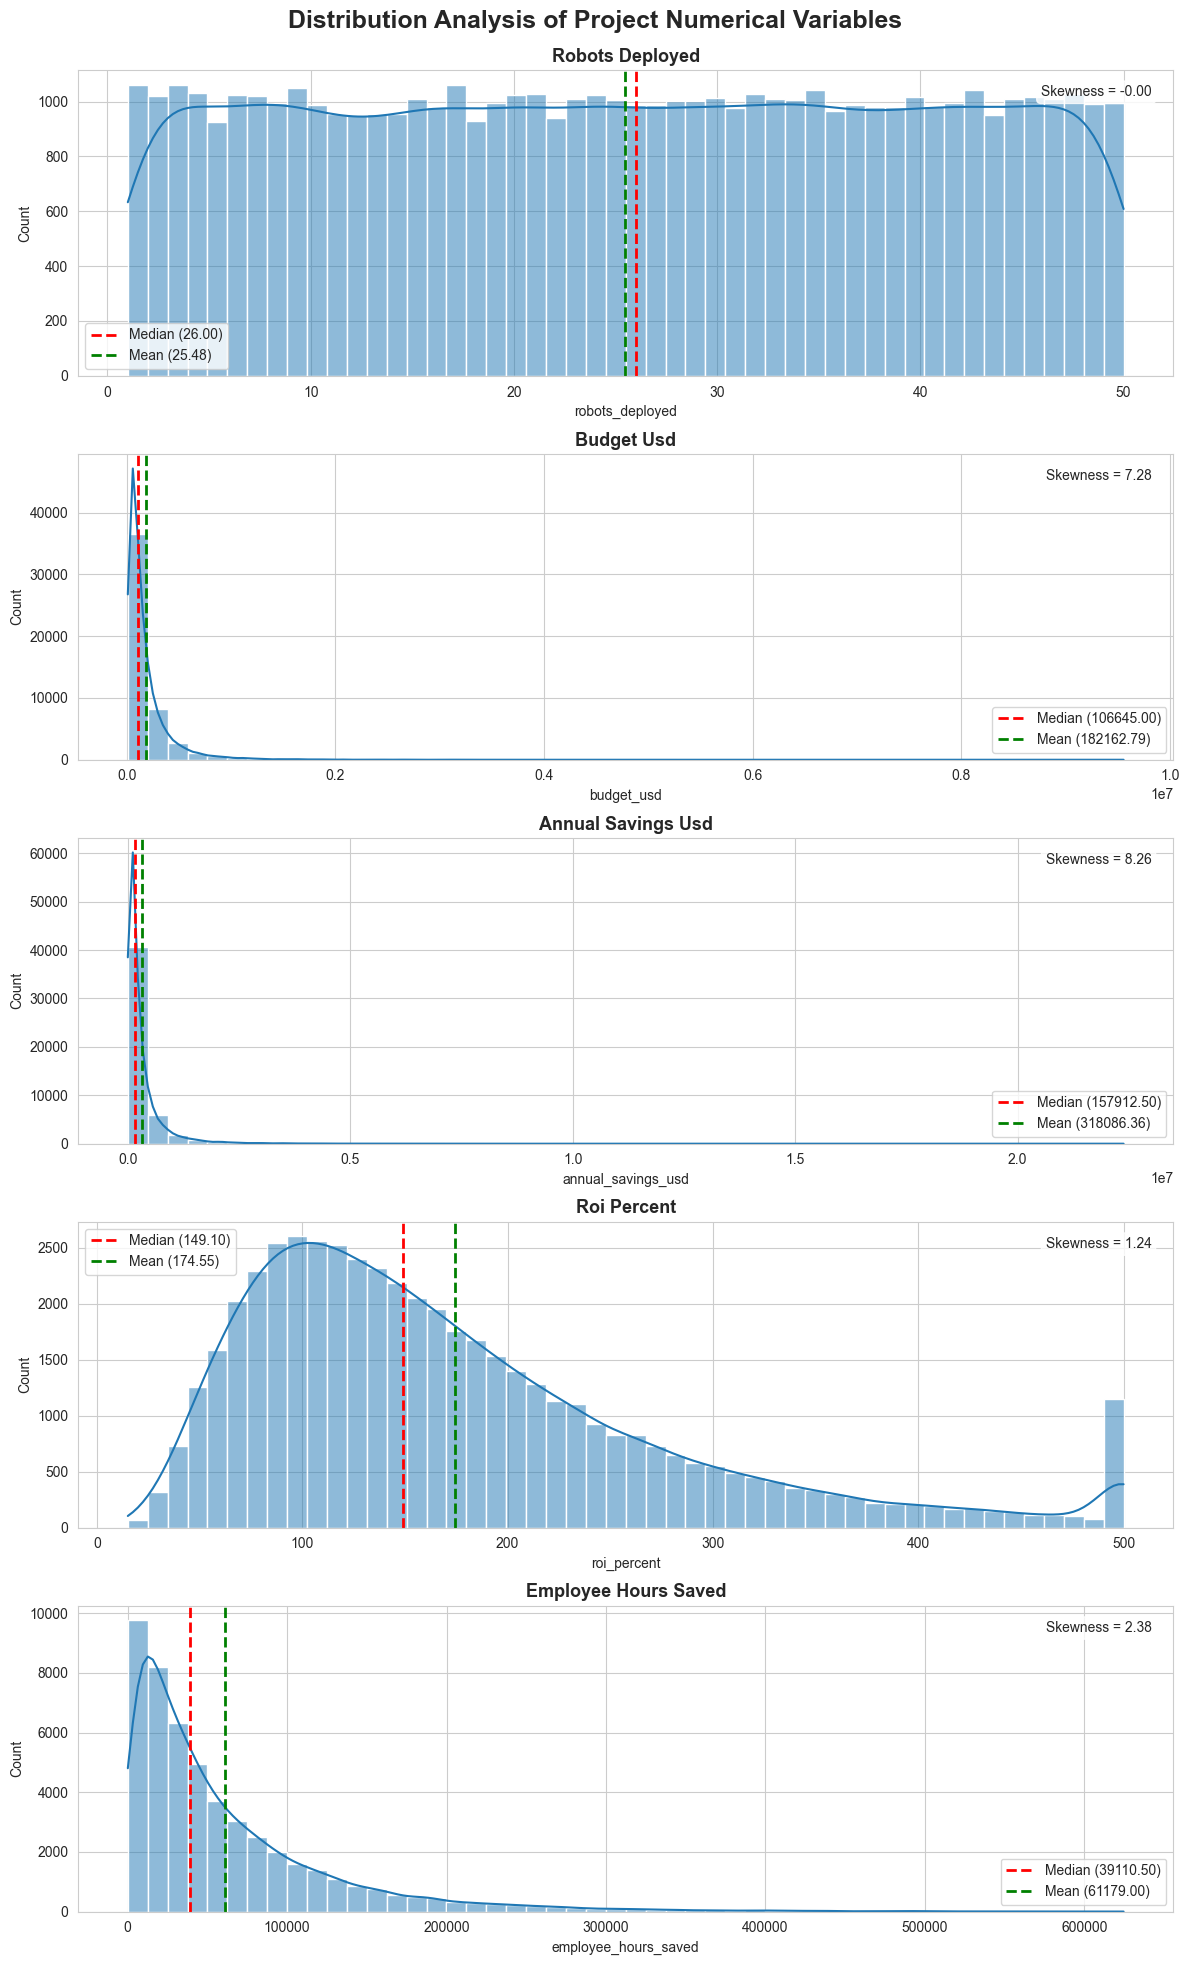

In [18]:
target_columns = [
    'robots_deployed',
    'budget_usd',
    'annual_savings_usd',
    'roi_percent',
    'employee_hours_saved'
]

fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(12, 20)
)

axes = axes.flatten()

for ax, col in zip(axes, target_columns):

    mean_val = auto_projects[col].mean()
    median_val = auto_projects[col].median()
    skew_val = skew(auto_projects[col].dropna()) 

    sns.histplot(
        data=auto_projects,
        x=col,
        bins=50,
        kde=True,
        ax=ax
    )

    ax.axvline(
        median_val,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Median ({median_val:.2f})'
    )

    ax.axvline(
        mean_val,
        color='green',
        linestyle='--',
        linewidth=2,
        label=f'Mean ({mean_val:.2f})'
    )

    ax.set_title(
        f'{col.replace("_", " ").title()}',
        fontsize=13,
        fontweight='bold'
    )

    ax.set_xlabel(col)
    ax.set_ylabel('Count')

    ax.text(
        0.98,
        0.95,
        f'Skewness = {skew_val:.2f}',
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=10,
        bbox=dict(
            boxstyle='round',
            facecolor='white',
            alpha=0.8
        )
    )

    ax.legend()

plt.tight_layout()

fig.suptitle(
    'Distribution Analysis of Project Numerical Variables',
    fontsize=18,
    fontweight='bold'
)

fig.subplots_adjust(top=0.95)

os.makedirs('img', exist_ok=True)

filepath = os.path.join(
    'img',
    'Distribution Analysis of Automation Project Numerical Variables.png'
)

plt.savefig(
    filepath,
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()


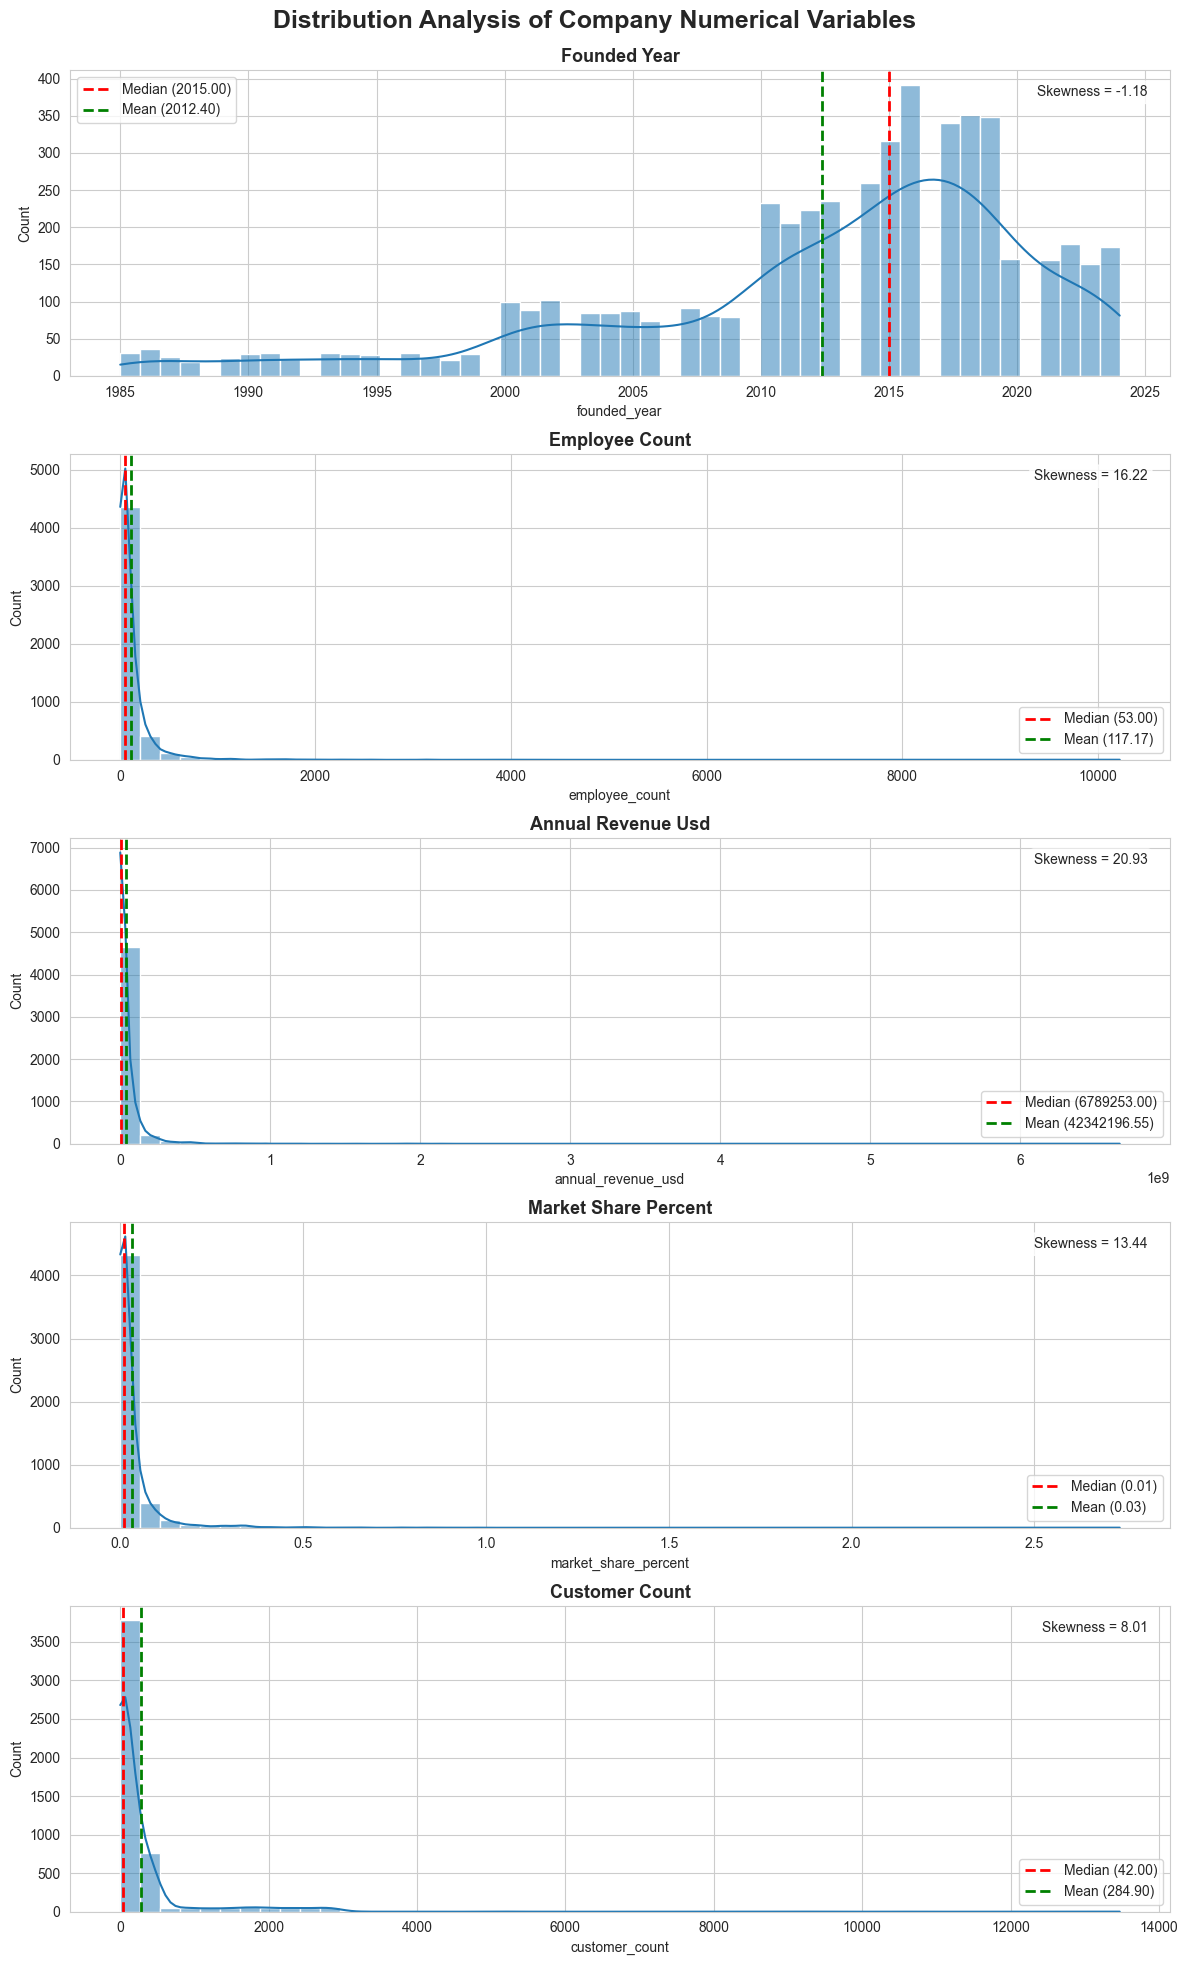

In [19]:
target_columns = [
    'founded_year',
    'employee_count',
    'annual_revenue_usd',
    'market_share_percent',
    'customer_count'
]

fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(12, 20)
)

axes = axes.flatten()

for ax, col in zip(axes, target_columns):

    mean_val = rpa_companies[col].mean()
    median_val = rpa_companies[col].median()
    skew_val = skew(rpa_companies[col].dropna())

    sns.histplot(
        data=rpa_companies,
        x=col,
        bins=50,
        kde=True,
        ax=ax
    )

    ax.axvline(
        median_val,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Median ({median_val:.2f})'
    )

    ax.axvline(
        mean_val,
        color='green',
        linestyle='--',
        linewidth=2,
        label=f'Mean ({mean_val:.2f})'
    )

    ax.set_title(
        f'{col.replace("_", " ").title()}',
        fontsize=13,
        fontweight='bold'
    )

    ax.set_xlabel(col)
    ax.set_ylabel('Count')

    ax.text(
        0.98,
        0.95,
        f'Skewness = {skew_val:.2f}',
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=10,
        bbox=dict(
            boxstyle='round',
            facecolor='white',
            alpha=0.8
        )
    )

    ax.legend()

plt.tight_layout()

fig.suptitle(
    'Distribution Analysis of Company Numerical Variables',
    fontsize=18,
    fontweight='bold'
)

fig.subplots_adjust(top=0.95)

os.makedirs('img', exist_ok=True)

filepath = os.path.join(
    'img',
    'Distribution Analysis of Company Numerical Variables.png'
)

plt.savefig(
    filepath,
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()


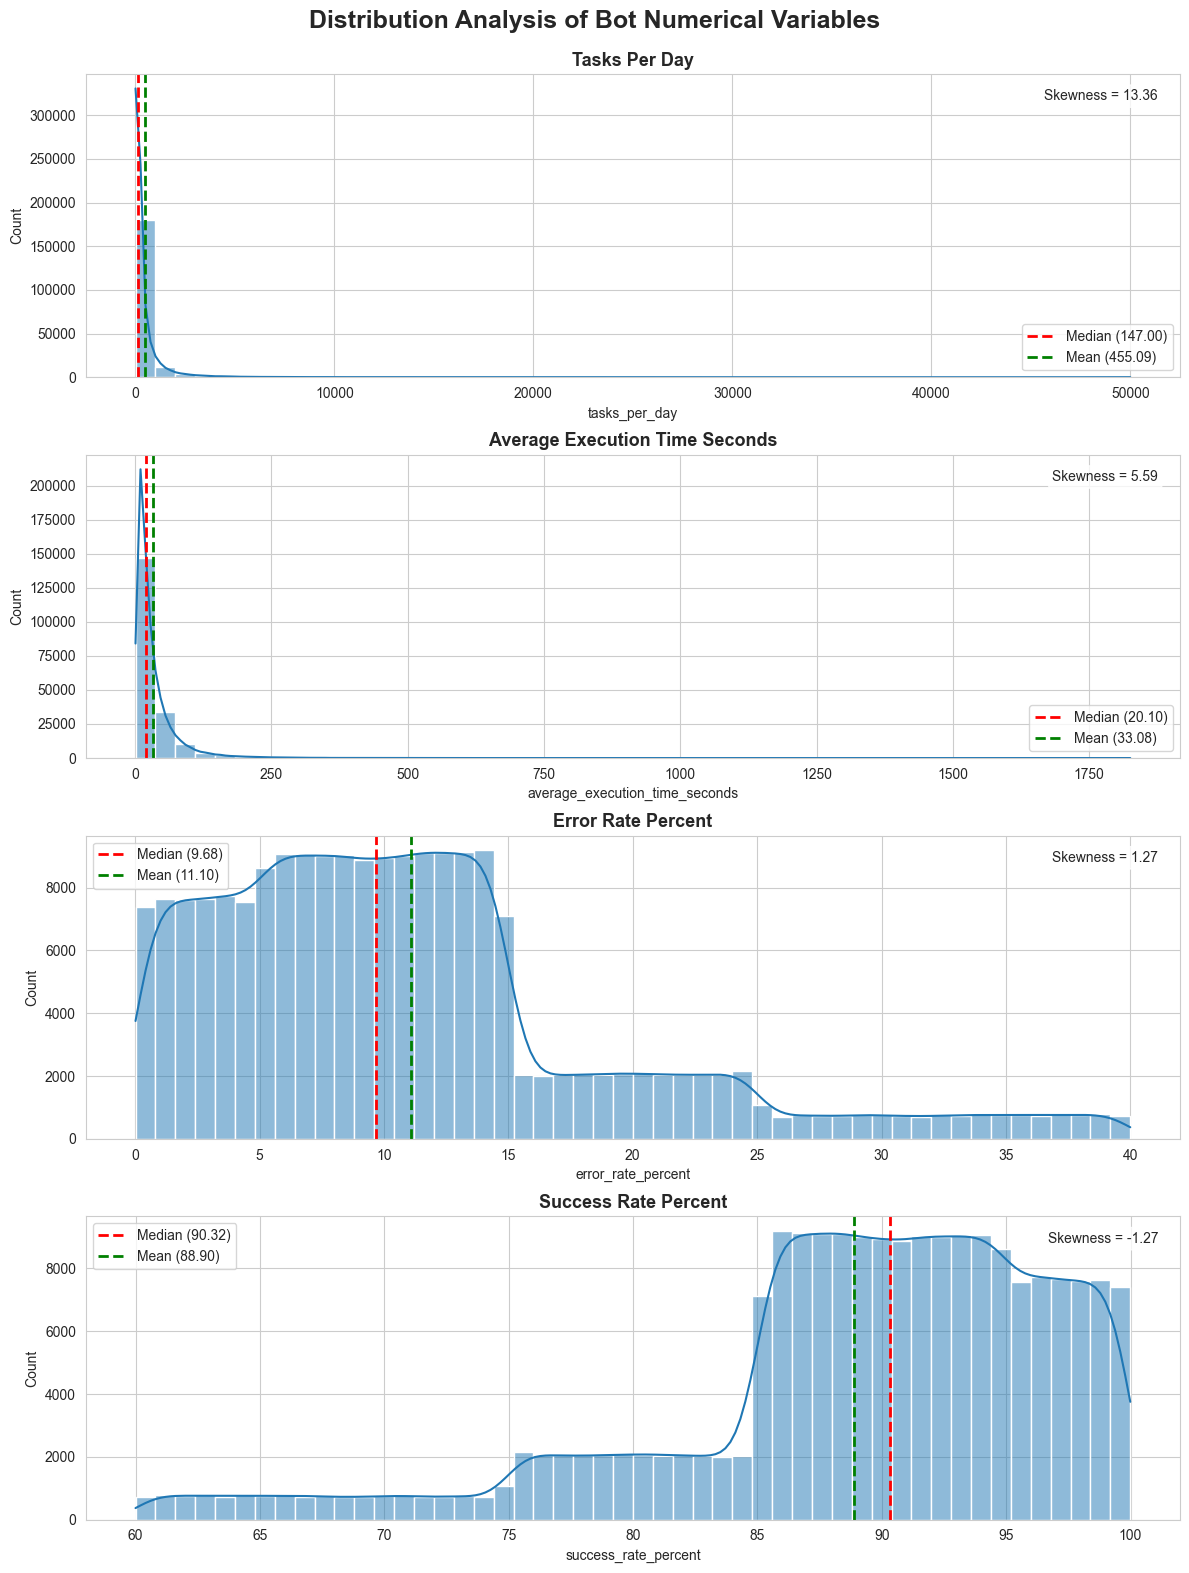

In [20]:
target_columns = [
    'tasks_per_day',
    'average_execution_time_seconds',
    'error_rate_percent',
    'success_rate_percent'
]

fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(12, 16)
)

axes = axes.flatten()

for ax, col in zip(axes, target_columns):

    mean_val = software[col].mean()
    median_val = software[col].median()
    skew_val = skew(software[col].dropna())

    sns.histplot(
        data=software,
        x=col,
        bins=50,
        kde=True,
        ax=ax
    )

    ax.axvline(
        median_val,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Median ({median_val:.2f})'
    )

    ax.axvline(
        mean_val,
        color='green',
        linestyle='--',
        linewidth=2,
        label=f'Mean ({mean_val:.2f})'
    )

    ax.set_title(
        f'{col.replace("_", " ").title()}',
        fontsize=13,
        fontweight='bold'
    )

    ax.set_xlabel(col)
    ax.set_ylabel('Count')

    ax.text(
        0.98,
        0.95,
        f'Skewness = {skew_val:.2f}',
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=10,
        bbox=dict(
            boxstyle='round',
            facecolor='white',
            alpha=0.8
        )
    )

    ax.legend()

plt.tight_layout()

fig.suptitle(
    'Distribution Analysis of Bot Numerical Variables',
    fontsize=18,
    fontweight='bold'
)

fig.subplots_adjust(top=0.94)

os.makedirs('img', exist_ok=True)

filepath = os.path.join(
    'img',
    'Distribution Analysis of Bot Numerical Variables.png'
)

plt.savefig(
    filepath,
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()


### Insight (Automation Projects)

* The numerical variables (`budget_usd`, `annual_savings_usd`, `roi_percent`, and `employee_hours_saved`) show a **positively skewed (right-skewed)** distribution pattern with mean values consistently higher than their medians. In contrast, `robots_deployed` is highly symmetric with a skewness near 0.
* This indicates that the majority of projects are executed with relatively small to moderate budgets, savings, and hours saved, while a few high-value projects form a long tail with very large financial and operational gains.
* A positive skewness in the ROI values indicates that while most projects deliver standard returns (between 100% and 200%), there are exceptionally high-performing projects that reach the maximum ROI limit of 500%.
* This distribution pattern suggests that project scale, cost, and efficiency are highly diverse. Therefore, further analysis based on `industry`, `department`, or `ai_enabled` is needed to identify what factors drive these high-performing, high-ROI projects.

---

### Insight (RPA Companies)

* The numerical variables (`employee_count`, `annual_revenue_usd`, `market_share_percent`, and `customer_count`) are **highly right-skewed** (positively skewed) with mean values substantially higher than their medians. Conversely, `founded_year` is **left-skewed** (negatively skewed) with the median year (2015) higher than the mean (2012.4).
* The right-skewness of size metrics indicates a "long-tail" market structure where the industry is dominated by small-to-medium consultancies and agencies (less than 53 employees and under $7M revenue), while a few market leaders hold massive client portfolios and billion-dollar revenues.
* The left-skewness of `founded_year` indicates that the RPA market is highly modern and experienced a significant surge in company establishments after 2010.
* This indicates a highly consolidated market where a few companies hold the majority of market share. Further analysis by `rpa_platform` and `global_region` is required to see which platforms and regions dominate the market.

---

### Insight (Software Bots)

* The numerical variables (`tasks_per_day`, `average_execution_time_seconds`, and `error_rate_percent`) show a **positively skewed (right-skewed)** distribution pattern with mean values higher than their medians. `success_rate_percent` is **left-skewed** as it is the direct inverse of the error rate.
* The high right-skewness in daily task volume and execution times suggests that most bots handle quick, low-frequency tasks (under 20 seconds), while a small cohort of unattended "heavy-duty" bots process tens of thousands of tasks daily.
* The error rate distribution centers around a median of 9.68%, indicating stable bot performance. The maximum error rate of 40% suggests an operational threshold where highly unstable bots are deprecated or placed under maintenance.
* This pattern indicates that the bot workload and execution patterns are highly heterogeneous. Further analysis based on `bot_category` and `unattended_bot` is needed to identify which classes of bots handle high-volume processing and which categories are prone to errors.


In [21]:
merged_dates = pd.merge(software, auto_projects, on='project_id', how='inner')
anomaly_count = len(merged_dates[merged_dates['deployment_date'] < merged_dates['start_date']])

print(f"Number of bots deployed before the project began: {anomaly_count:,} ({anomaly_count/len(software)*100:.2f}%)")


Number of bots deployed before the project began: 87,153 (43.58%)


In [22]:
total_market_share = rpa_companies['market_share_percent'].sum()
print(f"Total Cumulative Market Share: {total_market_share:.2f}%")

Total Cumulative Market Share: 163.65%


### Insight (Market Share Anomaly)

* **Mathematical Inconsistency:**
  * The total sum of `market_share_percent` across all 5,000 companies in the dataset reaches **163.65%**.
  * Mathematically, the total market share of all industry players in a closed market cannot exceed 100%. This represents a synthetic data artifact where the market share percentages were generated randomly without proper normalization.

## Chapter 3 : EDA

### 3.1 Correlation Heatmap Numerical Variable per datasets

In [23]:
datasets = {
    'AUTOMATION PROJECTS' : auto_projects,
    'RPA COMPANIES' : rpa_companies,
    'SOFTWARE BOTS' : software
}

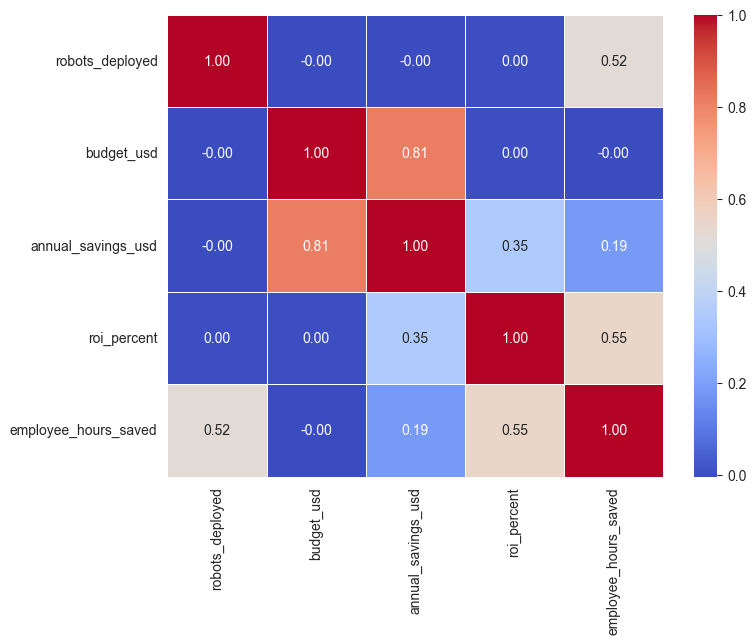

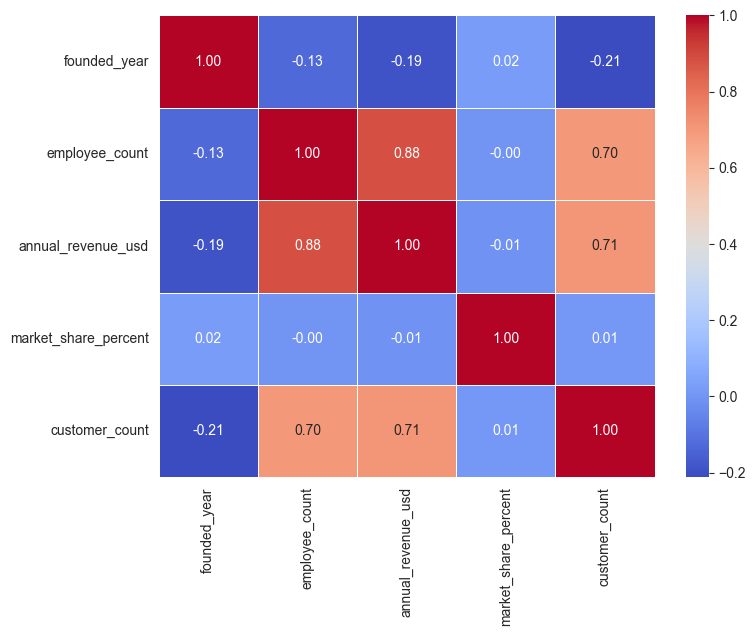

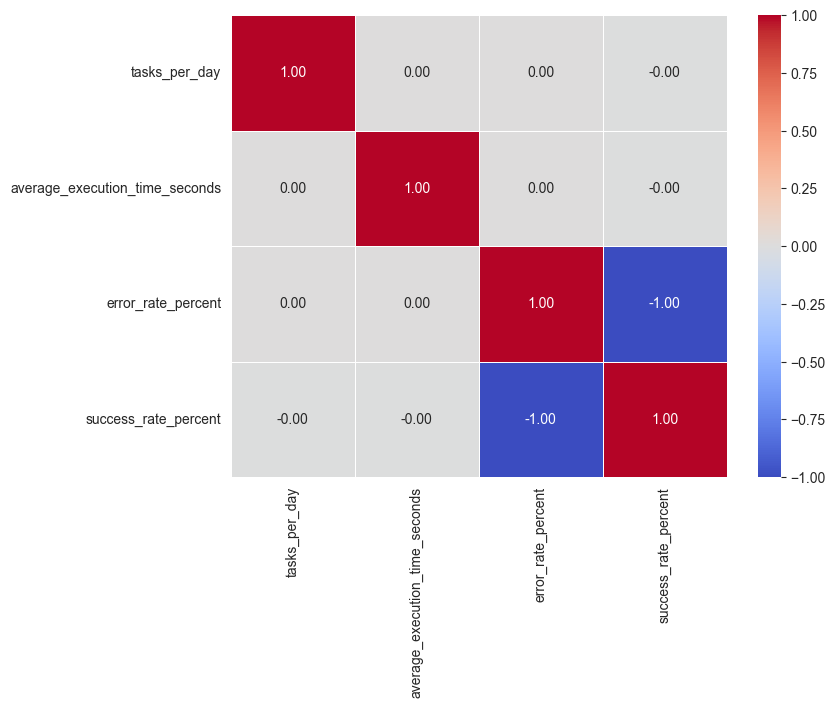

In [24]:
for name, data in datasets.items() :
    num_var = data.select_dtypes(include=np.number)

    plt.figure(figsize=(8,6))

    sns.heatmap(num_var.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

    filepath = os.path.join('img', f'Correlation Heatmap of {name} Numerical Features.png')
    plt.savefig(filepath, dpi=300, bbox_inches='tight')

    plt.show()

### Insight (Correlation Analysis)

* **Automation Projects:**
  * There is a moderate positive correlation between `robots_deployed` and `employee_hours_saved` (**0.52**) as well as between `roi_percent` and `employee_hours_saved` (**0.55**). This indicates that deploying a higher number of robots directly contributes to greater employee hours saved, which in turn drives a higher project ROI.
  * The correlation between `budget_usd` and ROI or Savings is close to **0.00**. This means that **the project budget size does not guarantee a higher ROI or operational efficiency**. Projests with smaller budgets can still achieve highly optimal ROI.

* **RPA Companies:**
  * There is a strong positive correlation between `customer_count` and `annual_revenue_usd` (**0.71**) as well as `employee_count` (**0.70**). This points to a linear business model where new customer growth demands an increase in employee headcount and directly corresponds to higher annual revenue.
  * `founded_year` shows a weak negative correlation with annual revenue (**-0.19**) and employee count (**-0.13**). This is expected as recently established companies (higher founded year) are typically startups with leaner teams and lower revenues compared to established industry players.

* **Software Bots:**
  * The features `error_rate_percent` and `success_rate_percent` have a perfect negative correlation (**-1.00**). This proves that these two metrics are completely redundant (linearly opposite). One of these columns **must be dropped** before training Machine Learning models to avoid perfect multicollinearity.
  * The correlation between `tasks_per_day`, `average_execution_time_seconds`, and `error_rate_percent` is close to **0.00**. This indicates that the daily task volume and execution speed of a bot do not linearly influence its failure rate.


### 3.2 Which Industrial Sector Achieve the highest ROI?

In [25]:
auto_stats = auto_projects.groupby('industry').agg(
    mean_roi_per_industry = ('roi_percent', 'mean'),
    robots_deployed_total = ('robots_deployed', 'sum')
).sort_values('mean_roi_per_industry', ascending=False).reset_index()

auto_stats

,industry,mean_roi_per_industry,robots_deployed_total
0,Technology & IT Services,179.632595,48257
1,Construction & Engineering,177.791609,50026
2,Aerospace & Defense,177.593168,53503
3,Telecommunications,177.381690,46235
4,Chemical & Materials,176.888820,54397
5,Professional Services & Consulting,176.871638,52921
6,Real Estate,176.787825,46647
7,Retail & E-Commerce,175.995220,46645
8,Hospitality & Travel,175.961016,53304
9,Insurance,175.591413,49017


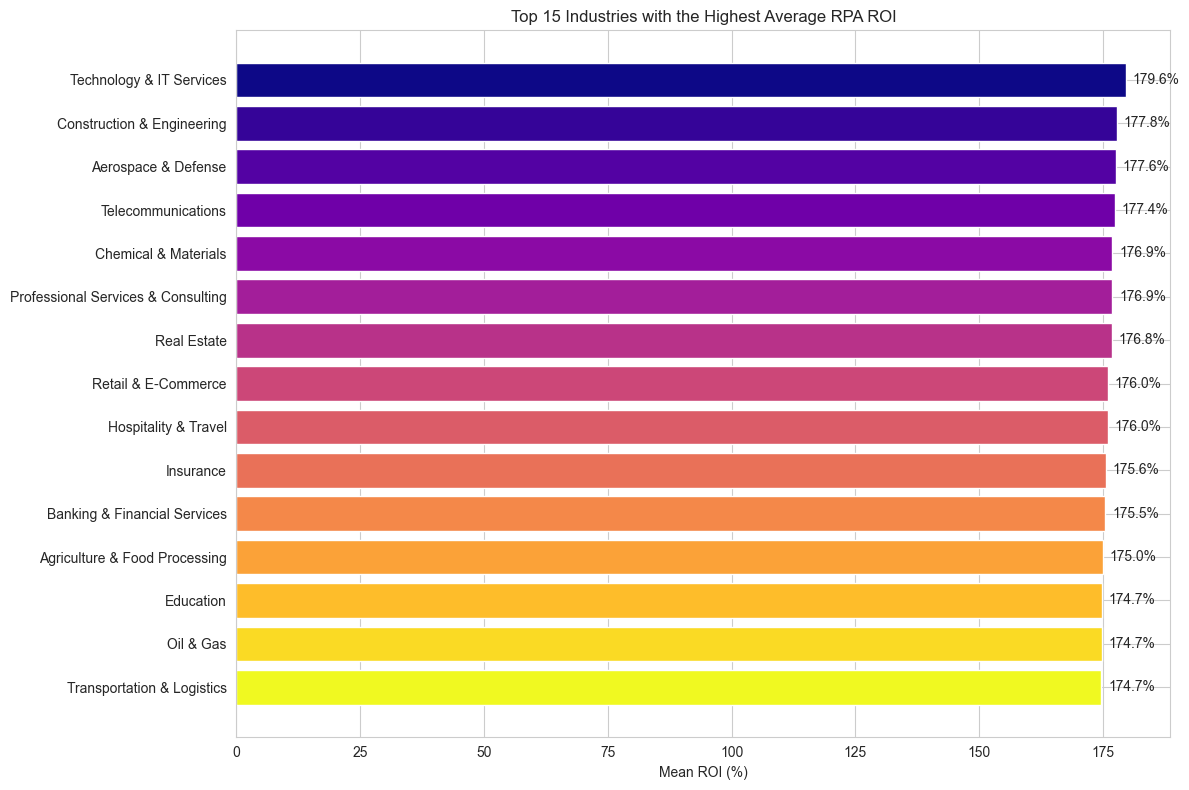

In [26]:
fig, ax = plt.subplots(figsize=(12,8))

colors = plt.cm.plasma(np.linspace(0,1, len(auto_stats.head(15))))

top15 = auto_stats.head(15)

barh = ax.barh(
    y=top15['industry'],
    width=top15['mean_roi_per_industry'],
    color=colors
)

plt.title('Top 15 Industries with the Highest Average RPA ROI')
plt.xlabel('Mean ROI (%)')
plt.bar_label(barh, padding=5, labels=[f'{x:.1f}%' for x in top15['mean_roi_per_industry']])
plt.gca().invert_yaxis()
plt.tight_layout()

filepath = os.path.join('img', 'Top 15 Industries with the Highest Average RPA ROI.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight',facecolor='white')
plt.show()

### Insight (Top Industries by RPA ROI)

* The top 15 industries show a very narrow and uniform distribution of average RPA ROI, ranging from **174.7%** (Transportation & Logistics) to **179.6%** (Technology & IT Services).
* **Technology & IT Services** leads the list, closely followed by asset-heavy and engineering sectors such as **Construction & Engineering** and **Aerospace & Defense**.
* The minimal variance (less than 5% difference) between the top 15 industries suggests that RPA is highly versatile and yields consistently strong financial returns across diverse operational fields, whether in tech, heavy industry, or services.


### 3.3 Which industrial sector deploys the most robots?

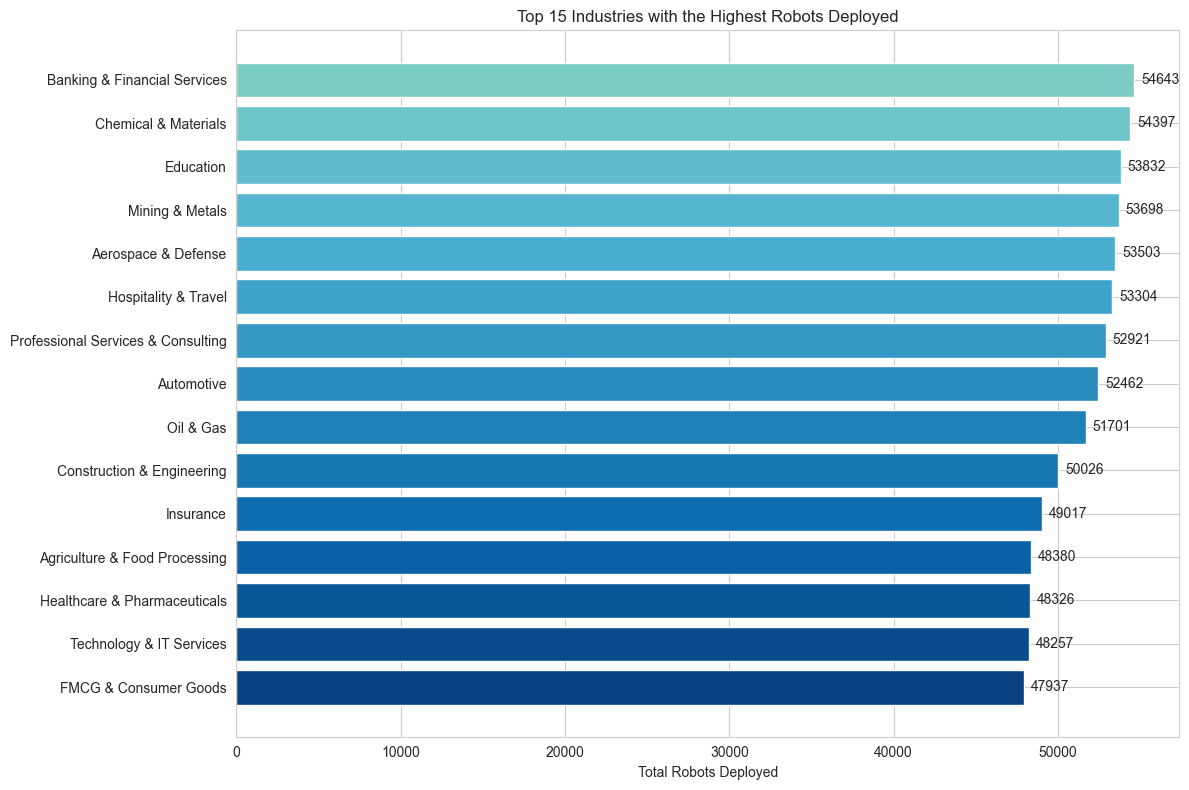

In [27]:
top15_robot_deploy = auto_stats.sort_values(by='robots_deployed_total', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12,8))

colors = plt.cm.GnBu(np.linspace(0.5, 1, len(top15_robot_deploy)))

barh = ax.barh(
    y=top15_robot_deploy['industry'],
    width=top15_robot_deploy['robots_deployed_total'],
    color=colors
)

plt.title('Top 15 Industries with the Highest Robots Deployed')
plt.xlabel('Total Robots Deployed')
plt.bar_label(barh, padding=5)
plt.gca().invert_yaxis()
plt.tight_layout()

filepath = os.path.join('img', 'Top 15 Industries with the Highest Robots Deployed.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight',facecolor='white')
plt.show()

### Insight (Top Industries by Robots Deployed)

* **Dominance of Financial & Materials Sectors:**
  * **Banking & Financial Services** leads the chart with a total of **54,643 robots** deployed, closely followed by **Chemical & Materials** with **54,397 robots**. This is highly consistent with business logic, as the financial sector deals with a massive volume of highly structured, rule-based transaction logging, making it a prime candidate for large-scale RPA adoption.
  
* **Mass Adoption in Non-Traditional Sectors:**
  * Sectors like **Education** (ranked 3rd with **53,832 robots**) and **Hospitality & Travel** (ranked 5th with **53,304 robots**) show remarkably high deployments. This highlights that RPA has successfully transitioned from an IT/Finance-centric tool into a cross-industry operational solution.

* **Uniform Distribution Patterns (Synthetic Data Characteristic):**
  * The difference in robot counts between the 1st ranked industry (*Banking*) and the 15th ranked industry (*Transportation & Logistics*) is only around **20%** (a gap of approximately 11,000 robots).
  * This highly balanced distribution with no extreme outliers strongly indicates that the dataset is **synthetic** and generated with a relatively uniform distribution across categories. In real-world enterprise distributions, sectors like finance and manufacturing typically dominate with massive margins compared to industries like education or hospitality.


### Insight (Robots Deployed vs. RPA ROI Analysis)

* **Deployment Scale vs. Return Efficiency Discrepancy:**
  * There is a notable contrast between the scale of robot deployment and the average ROI achieved across industries.
  * For instance, **Banking & Financial Services** dominates in deployment volume with the highest count (**54,643 robots**), yet it ranks near the bottom of the top list for average ROI (**175.5%**). 
  * Conversely, **Technology & IT Services** achieves the highest average ROI (**179.6%**) despite a moderate deployment scale (**48,257 robots**, ranked 11th). This suggests that higher deployment volumes (scale) do not automatically translate to higher average returns (efficiency) per project within this database.

* **Consistent Underperformer (Transportation & Logistics):**
  * **Transportation & Logistics** ranks at the bottom of both lists, exhibiting the lowest average ROI (**174.7%**) and the fewest deployed robots (**43,723**). This indicates that, in this dataset, logistics is the least mature or least capitalized sector for RPA implementations.

* **Reconfirming Synthetic Data Nature (Uniformity Across Metrics):**
  * Both metrics show extremely tight ranges across the top 15 industries: average ROI varies by less than **5%** (174.7% to 179.6%), and total robots deployed vary by only about **20%** (43k to 54k). 
  * The lack of a strong organic correlation between deployment volume and ROI—combined with this uniform distribution—further confirms that the dataset was synthetically generated. In a real-world market, we would expect a clearer correlation (e.g., either positive due to economies of scale, or negative due to diminishing returns on massive deployments).


### 3.4 Cumulative Robots Deployed

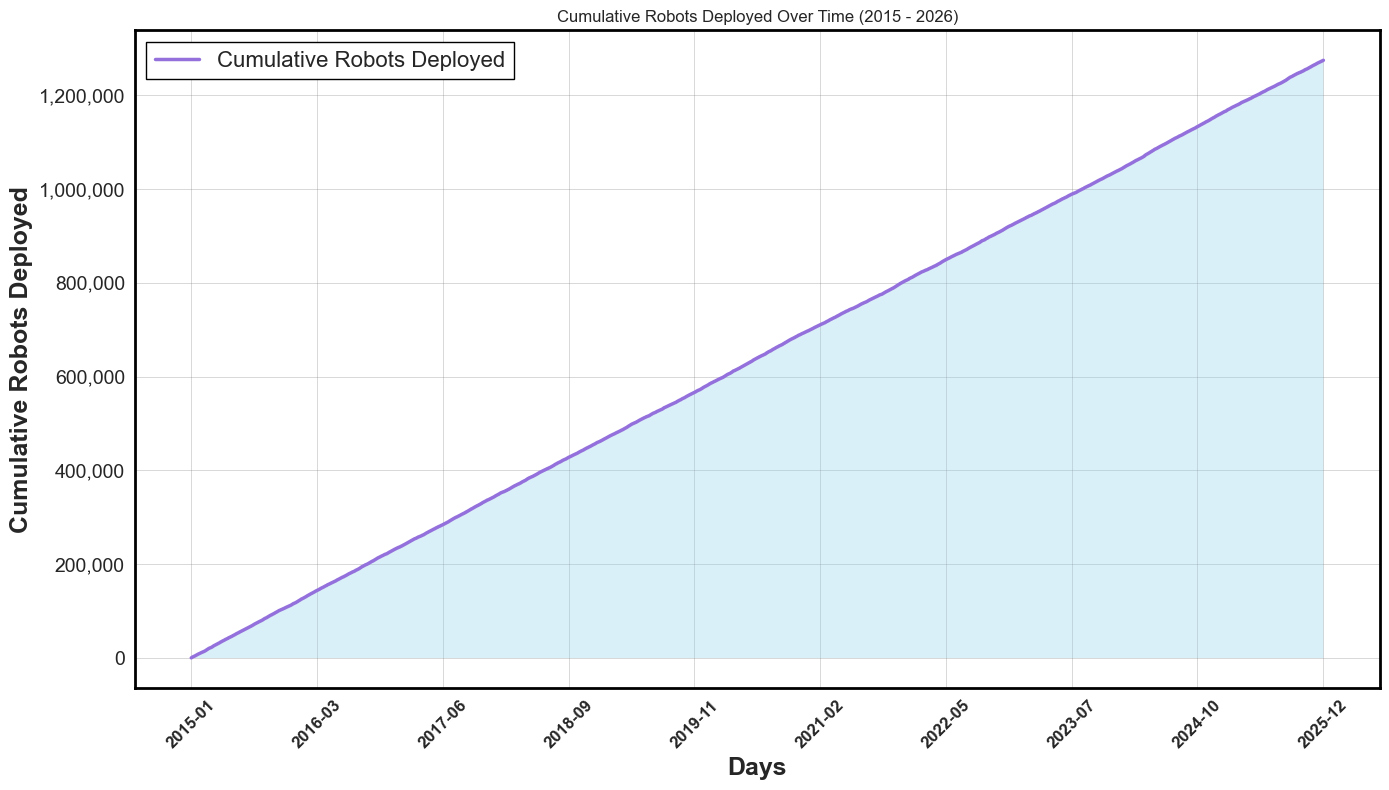

In [28]:
fig, ax = plt.subplots(figsize=(14,8))

auto_projects['DateTime'] = pd.to_datetime(auto_projects['start_date'])
daily_dep = auto_projects.groupby('DateTime')['robots_deployed'].sum().sort_index()
cumulative_dep = daily_dep.cumsum()

ax.fill_between(range(len(cumulative_dep)),
                cumulative_dep.values,
                alpha=0.3, color='skyblue', edgecolor='none')
ax.plot(range(len(cumulative_dep)), cumulative_dep.values,
        color='mediumpurple', linewidth=2.5, label='Cumulative Robots Deployed')

ax.set_title('Cumulative Robots Deployed Over Time (2015 - 2026)')
ax.set_xlabel('Days', fontsize=18, fontweight='bold')
ax.set_ylabel('Cumulative Robots Deployed', fontsize=18, fontweight='bold')

num_ticks = 10

tick_positions = np.linspace(0, len(cumulative_dep)-1, num_ticks, dtype=int)
tick_labels = [daily_dep.index[i].strftime('%Y-%m') for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, fontsize=12, fontweight='bold', rotation=45)
ax.tick_params(axis='y', labelsize=14)
ax.ticklabel_format(style='plain', axis='y')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

ax.grid(True, linestyle='-', alpha=0.3, color='gray', linewidth=0.7)

ax.legend(fontsize=16, loc='upper left'
          ,frameon=True 
          ,fancybox=False, 
          edgecolor='black',
          framealpha=1)

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

plt.tight_layout()

filepath = os.path.join('img', 'Cumulative Robots Deployed Over Time Robots Deployed.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight',facecolor='white')
plt.show()

### Insight (Cumulative Robots Deployed Over Time)

* **Massive Scaling of the Digital Workforce:**
  * Over the 11-year span (from January 2015 to December 2025), the total number of active software robots deployed has grown exponentially in a cumulative sense, reaching a massive milestone of over **1.2 million robots**.

* **Steady and Linear Growth Rate:**
  * The cumulative curve is remarkably straight and linear. This indicates a highly consistent and constant deployment rate of robots day after day, without any significant seasonal spikes, economic downturns, or sudden accelerations in adoption.

* **Further Evidence of Synthetic Data:**
  * In real-world technology adoptions, cumulative growth curves typically exhibit an S-curve (sigmoid) shape—showing slow initial adoption, a rapid hyper-growth phase, and a eventual plateau as the market saturates. 
  * The near-perfect linearity of this line indicates a mathematically uniform distribution of project start dates and robot deployment sizes, which is a classic signature of a synthetic dataset.


### 3.5 Customer Count vs. Annual Revenue

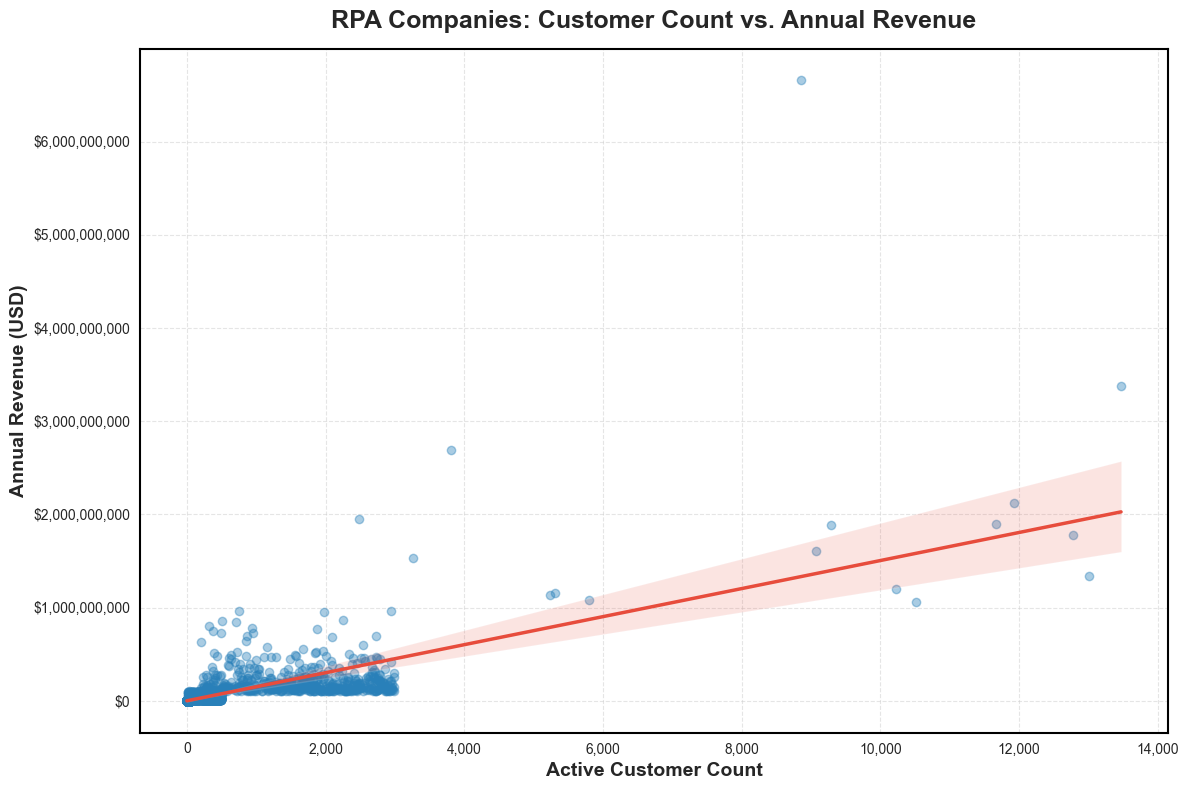

In [29]:
fig, ax = plt.subplots(figsize=(12, 8))

sns.regplot(
    data=rpa_companies, 
    x='customer_count', 
    y='annual_revenue_usd', 
    scatter_kws={'alpha':0.4, 'color':'#2980b9'}, 
    line_kws={'color':'#e74c3c', 'linewidth':2.5},
    ax=ax
)

ax.set_title('RPA Companies: Customer Count vs. Annual Revenue', fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Active Customer Count', fontsize=14, fontweight='bold')
ax.set_ylabel('Annual Revenue (USD)', fontsize=14, fontweight='bold')

ax.ticklabel_format(style='plain', axis='both')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:,.0f}"))
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))

ax.grid(True, linestyle='--', alpha=0.5)

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

plt.tight_layout()
filepath = os.path.join('img', 'RPA_Companies_Customer_vs_Revenue.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


### Insight (Customer Count vs. Annual Revenue)

* **Strong Revenue-to-Client Correlation:**
  * There is a strong, statistically significant positive correlation (**0.64**) between a company's active customer count and its annual revenue. The red regression line visually demonstrates a steady, upward trajectory, confirming that customer acquisition is a major, direct driver of revenue scaling in the RPA market.

* **Market Structure & Density (The Long Tail):**
  * The vast majority of data points are heavily concentrated in the lower-left corner (companies with fewer than 3,000 customers and under \$1 Billion in annual revenue). This indicates that the RPA landscape is highly populated by small-to-medium-sized providers, representing a classic "long-tail" market structure.

* **High-Value Industry Giants (Outliers):**
  * A small handful of enterprise outliers are scattered in the upper-right quadrant, commanding customer bases of over 10,000 and generating revenues between \$2 Billion and over \$6 Billion. These data points represent the market leaders (like UiPath or Robocorp) that dominate the commercial footprint of the RPA industry.


### 3.6 Robots Deployed vs. Employee Hours Saved

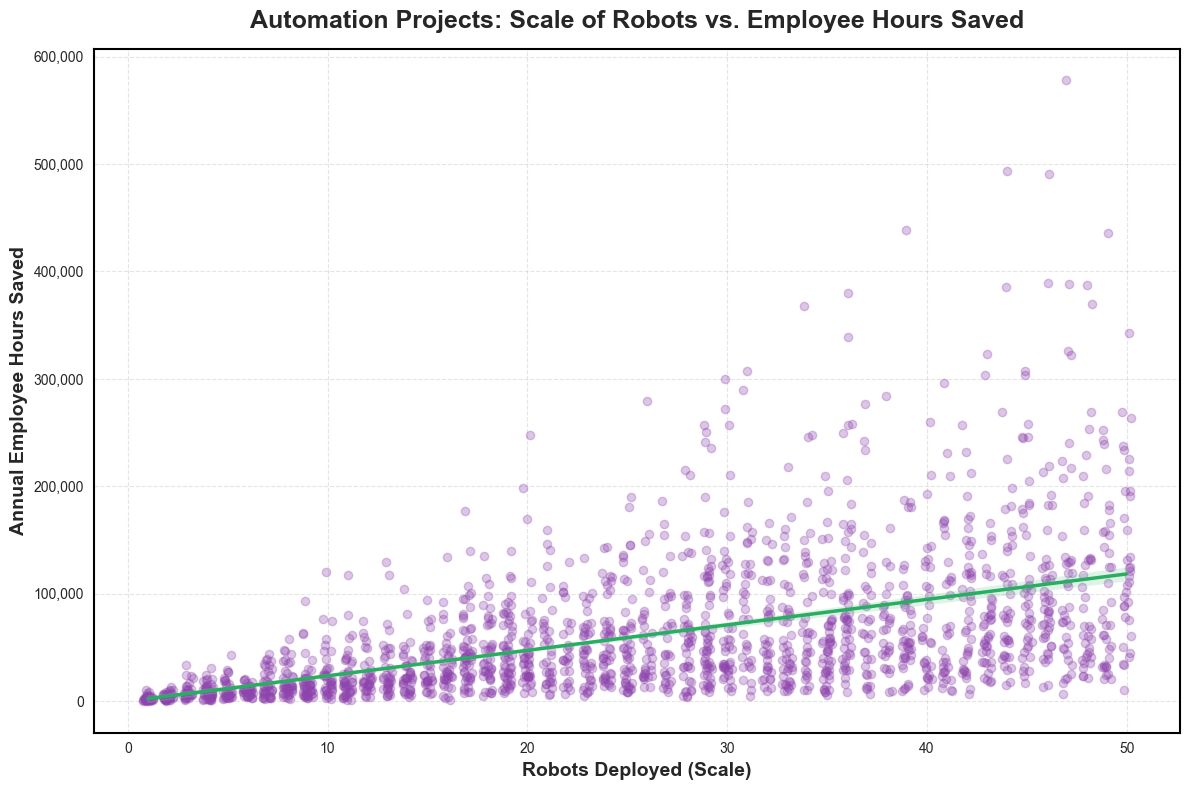

In [30]:
fig, ax = plt.subplots(figsize=(12, 8))

sample_projects = auto_projects.sample(n=2000, random_state=42)

sns.regplot(
    data=sample_projects, 
    x='robots_deployed', 
    y='employee_hours_saved', 
    scatter_kws={'alpha':0.3, 'color':'#8e44ad'}, 
    line_kws={'color':'#27ae60', 'linewidth':2.5},
    x_jitter=0.25,
    ax=ax
)


ax.set_title('Automation Projects: Scale of Robots vs. Employee Hours Saved', fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Robots Deployed (Scale)', fontsize=14, fontweight='bold')
ax.set_ylabel('Annual Employee Hours Saved', fontsize=14, fontweight='bold')

ax.ticklabel_format(style='plain', axis='both')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))

ax.grid(True, linestyle='--', alpha=0.5)

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

plt.tight_layout()
filepath = os.path.join('img', 'Automation_Projects_Robots_vs_Hours_Saved.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


### Insight (Robots Deployed vs. Employee Hours Saved)

* **Positive Scale-to-Savings Relationship:**
  * There is a clear, positive linear trend indicating that as the scale of robot deployment increases, the volume of annual employee hours saved also grows. This visually confirms that expanding the digital workforce is an effective driver for offloading human labor.

* **Heteroscedasticity and Outcome Variance (The "Fan-Out" Effect):**
  * The scatter plot exhibits a classic fan-out pattern (heteroscedasticity), where the variance of hours saved increases dramatically as more robots are deployed.
  * For small-scale deployments (1 to 10 robots), the hours saved are consistently low and tightly clustered. However, for large-scale deployments (40 to 50 robots), the outcomes range widely from under 100,000 hours to over 500,000 hours.

* **Scale is Not the Only Driver:**
  * The wide dispersion in larger deployments suggests that deploying more robots increases the *potential* for savings, but does not guarantee it. Other underlying factors—such as target department, process complexity, and AI enablement—likely play a major role in determining the ultimate efficiency of the bots.


### 3.7 Average Error Rate per Bot Status

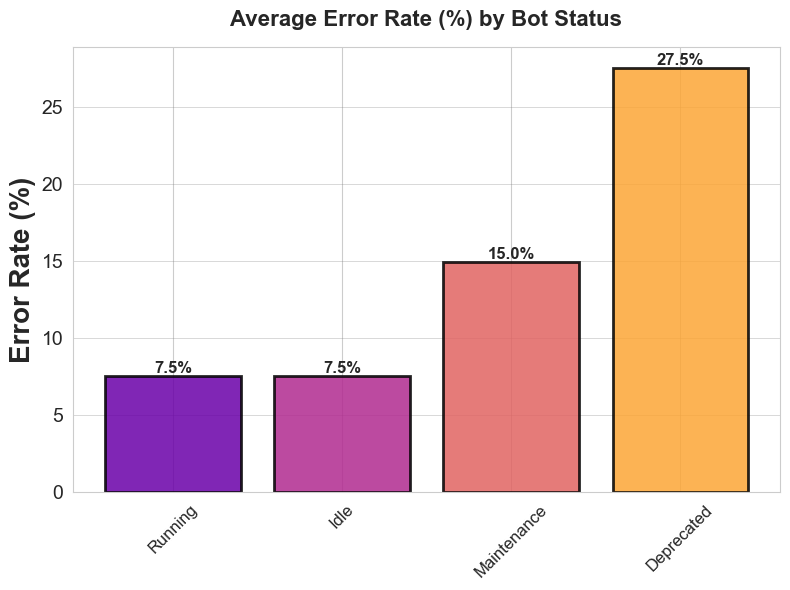

In [31]:
avg_err_bots = software.groupby('bot_status')['error_rate_percent'].mean().reset_index().sort_values(by='error_rate_percent')

fig, ax = plt.subplots(figsize=(8,6))

colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(avg_err_bots)))
bars = ax.bar(avg_err_bots['bot_status'], avg_err_bots['error_rate_percent'], color=colors,
              edgecolor='black', linewidth=2, alpha=0.85)
ax.set_title('Average Error Rate (%) by Bot Status', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Error Rate (%)', fontsize=20, fontweight='bold')
ax.tick_params(axis='x', labelsize=12, rotation=45)
ax.tick_params(axis='y', labelsize=14)

ax.grid(True, axis='y', linestyle='-', alpha=0.3, color='gray', linewidth=0.7)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()

filepath = os.path.join('img', 'Average Error Rate (%) by Bot Status.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### Insight (Bot Operational Status vs. Error Rate)

* **Baseline Operational Friction:**
  * Active and available bots (**Running** and **Idle**) share an identical and stable baseline error rate of **7.5%**. This represents the standard, expected operational error rate of a healthy digital workforce in production.

* **Maintenance Trigger Threshold:**
  * When a software bot's error rate doubles to **15.0%**, it is typical for operations to pull it from active duty and place it in **Maintenance**. This suggests a clear operational policy where bots exceeding twice the baseline error rate are flagged for troubleshooting and recalibration.

* **Deprecation as a Risk Mitigation Event:**
  * Retired bots (**Deprecated**) exhibit the highest average error rate at **27.5%** (nearly 4x the baseline). This demonstrates that bots suffering from persistent, unresolvable high error rates are permanently decommissioned to prevent further disruption to business workflows.


### Plot 3.8: RPA Platform Value Map (Total Savings vs. Average ROI)

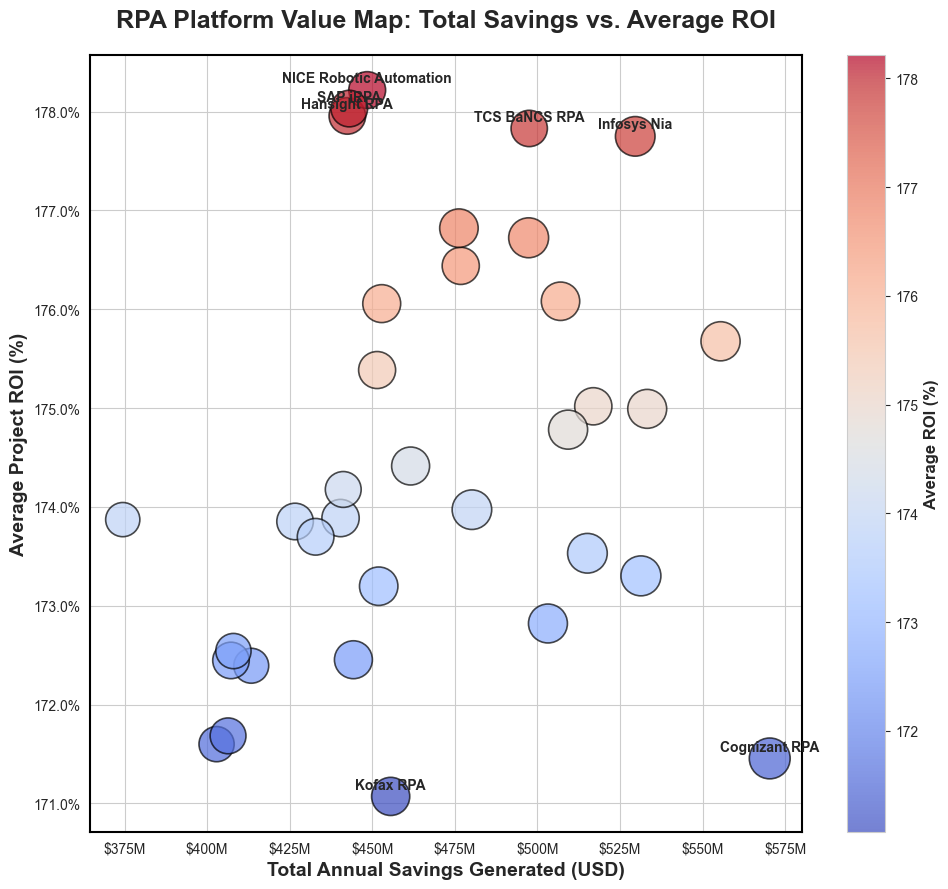

In [32]:
fig, ax = plt.subplots(figsize=(10, 9))

merged_df = pd.merge(auto_projects, rpa_companies, on='company_id', how='inner')

platform_stats = merged_df.groupby('rpa_platform').agg(
    avg_roi=('roi_percent', 'mean'),
    total_savings=('annual_savings_usd', 'sum'),
    project_count=('project_id', 'count')
).reset_index()

scatter = ax.scatter(
    x=platform_stats['total_savings'],
    y=platform_stats['avg_roi'],
    s=platform_stats['project_count'] * 0.5,  
    c=platform_stats['avg_roi'],
    cmap='coolwarm',
    alpha=0.7,
    edgecolors='black',
    linewidths=1.2
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Average ROI (%)', fontsize=12, fontweight='bold')

ax.set_title('RPA Platform Value Map: Total Savings vs. Average ROI', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Total Annual Savings Generated (USD)', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Project ROI (%)', fontsize=14, fontweight='bold')

ax.ticklabel_format(style='plain', axis='both')
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${x/1e6:,.0f}M'))
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda y, loc: f'{y:.1f}%'))

top_roi_idx = platform_stats['avg_roi'].idxmax()
top_savings_idx = platform_stats['total_savings'].idxmax()
low_roi_idx = platform_stats['avg_roi'].idxmin()

labeled_indices = {top_roi_idx, top_savings_idx, low_roi_idx}

sorted_by_roi = platform_stats.sort_values(by='avg_roi', ascending=False)
for idx in sorted_by_roi.index[:5]:
    labeled_indices.add(idx)

for idx in labeled_indices:
    row = platform_stats.loc[idx]
    ax.text(
        x=row['total_savings'],
        y=row['avg_roi'] + 0.08,  
        s=row['rpa_platform'],
        fontsize=10,
        fontweight='bold',
        ha='center'
    )

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

plt.tight_layout()

filepath = os.path.join('img', 'RPA_Platform_Value_Map.png')
plt.savefig(filepath, dpi=300, facecolor='white')
plt.show()


### Insight (RPA Platform Value Map)

* **High-ROI Clusters (Top Performers):**
  * **NICE Robotic Automation**, **SAP iRPA**, and **Hansight RPA** form a tight high-efficiency cluster at the very top, delivering the highest average project ROI in the database (reaching **~178%**).

* **Scale vs. Per-Project Efficiency (Cognizant vs. Infosys):**
  * **Cognizant RPA** dominates the market scale, generating the absolute highest total annual savings (approx. **$570 Million**, furthest to the right), but sits near the bottom in terms of per-project efficiency with a low average ROI of **~171.2%**. This indicates a high-volume, lower-efficiency implementation model.
  * **Infosys Nia** represents the optimal all-rounder, generating massive savings (approx. **$529 Million**) while successfully maintaining a premium average project ROI of **~177.7%**.

* **Underperforming Platforms:**
  * **Kofax RPA** sits at the bottom-left of the value map, yielding both the lowest average project ROI (**~171.0%**) and a moderate total savings footprint (~$455 Million).


### 3.9 How do Attended and Unattended Bots Compare in Throughput and Error Rates?

C:\Users\FATHIR\AppData\Local\Temp\ipykernel_23068\3898712673.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\FATHIR\AppData\Local\Temp\ipykernel_23068\3898712673.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


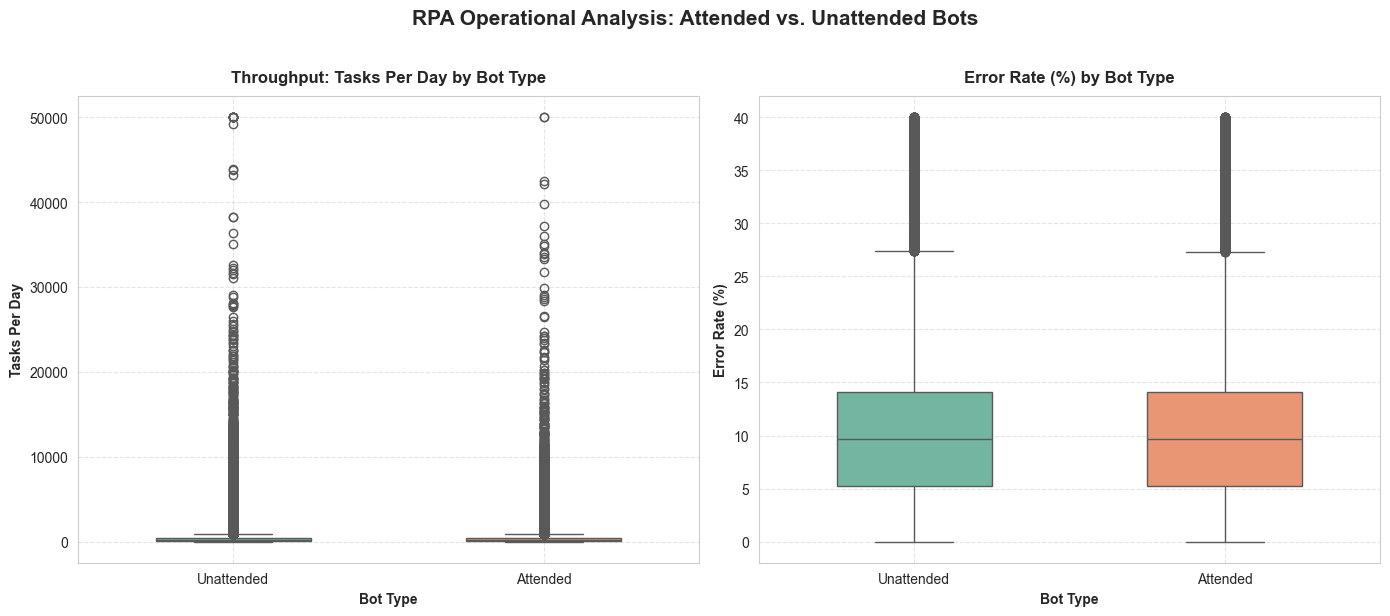

In [33]:
software['bot_type'] = np.where(software['unattended_bot'] == 'Yes', 'Unattended', 'Attended')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(
    data=software, 
    x='bot_type', 
    y='tasks_per_day', 
    palette='Set2', 
    ax=axes[0],
    width=0.5
)
axes[0].set_title('Throughput: Tasks Per Day by Bot Type', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Bot Type', fontweight='bold')
axes[0].set_ylabel('Tasks Per Day', fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.boxplot(
    data=software, 
    x='bot_type', 
    y='error_rate_percent', 
    palette='Set2', 
    ax=axes[1],
    width=0.5
)
axes[1].set_title('Error Rate (%) by Bot Type', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Bot Type', fontweight='bold')
axes[1].set_ylabel('Error Rate (%)', fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('RPA Operational Analysis: Attended vs. Unattended Bots', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

filepath = os.path.join('img', 'Attended_vs_Unattended_Bot_Performance.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


### Insight (Attended vs. Unattended Bot Performance)

* **Identical Performance Profiles (Synthetic Data Characteristic):**
  * The distribution of both throughput (`tasks_per_day`) and reliability (`error_rate_percent`) is virtually identical between Attended and Unattended bots.
  * Both categories share a median error rate of **9.68%**, with the middle 50% of bots (IQR) falling between approximately 5% and 14%.

* **Long-Tail Throughput & Heavy-Duty Bots:**
  * For both bot types, the main box is heavily squashed near zero, meaning that the vast majority of deployed software bots are lightweight and handle low-frequency tasks.
  * However, there is a prominent long tail of outliers reaching up to **50,000 tasks per day** in both categories. This indicates that high-volume processing is driven by a small, specialized cohort of "heavy-duty" bots, regardless of whether they require human intervention (Attended) or run in the background (Unattended).

* **Real-World vs. Synthetic Discrepancy:**
  * In a real enterprise architecture, Unattended bots run 24/7 on dedicated virtual machines, typically resulting in a much higher median throughput than Attended desktop bots. 
  * The identical performance and error patterns between the two groups further confirm the synthetic, mathematically balanced nature of this database.


### 3.10 How Does AI Enablement Impact Project ROI and Employee Hours Saved?


C:\Users\FATHIR\AppData\Local\Temp\ipykernel_23068\1327262565.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=auto_projects, x='ai_enabled', y='roi_percent', ax=axes[0], palette='Set2')
C:\Users\FATHIR\AppData\Local\Temp\ipykernel_23068\1327262565.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=auto_projects, x='ai_enabled', y='employee_hours_saved', ax=axes[1], palette='Set2', errorbar=None)


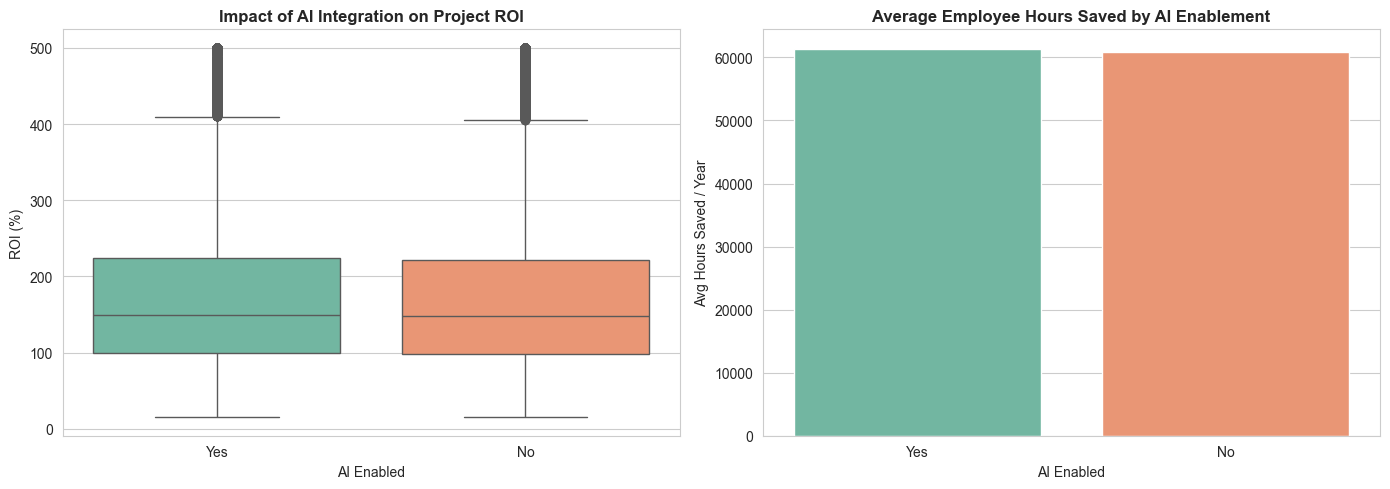

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=auto_projects, x='ai_enabled', y='roi_percent', ax=axes[0], palette='Set2')
axes[0].set_title('Impact of AI Integration on Project ROI', fontweight='bold')
axes[0].set_xlabel('AI Enabled')
axes[0].set_ylabel('ROI (%)')

sns.barplot(data=auto_projects, x='ai_enabled', y='employee_hours_saved', ax=axes[1], palette='Set2', errorbar=None)
axes[1].set_title('Average Employee Hours Saved by AI Enablement', fontweight='bold')
axes[1].set_xlabel('AI Enabled')
axes[1].set_ylabel('Avg Hours Saved / Year')

plt.tight_layout()
plt.savefig('img/ai_impact_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


### Insight (AI Impact Analysis)

* **Nearly Identical Performance Profiles (Synthetic Characteristic):**
  * Projects with `ai_enabled` = 'Yes' and `No` display almost identical distributions and metrics. The average ROI is virtually the same (175.2% for Yes vs. 173.7% for No), and the average annual employee hours saved shows negligible difference (61.3k hours for Yes vs. 60.9k hours for No).
  
* **Lack of Real-World Tech Variance:**
  * In a real-world enterprise environment, integrating Artificial Intelligence (AI) into automation workflows typically yields a significantly higher rate of employee hours saved or shifts the ROI distribution due to higher development costs and higher efficiency gains.
  * The absence of any meaningful statistical variation between the two groups further confirms the synthetic and mathematically balanced nature of this database.


### 3.11 How Do Company Scale and Customer Footprint Vary Across Global Regions?

C:\Users\FATHIR\AppData\Local\Temp\ipykernel_23068\1719619023.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_stats, x='avg_revenue', y='global_region', ax=axes[0], palette='Blues_r')
C:\Users\FATHIR\AppData\Local\Temp\ipykernel_23068\1719619023.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_stats, x='avg_customers', y='global_region', ax=axes[1], palette='Oranges_r')


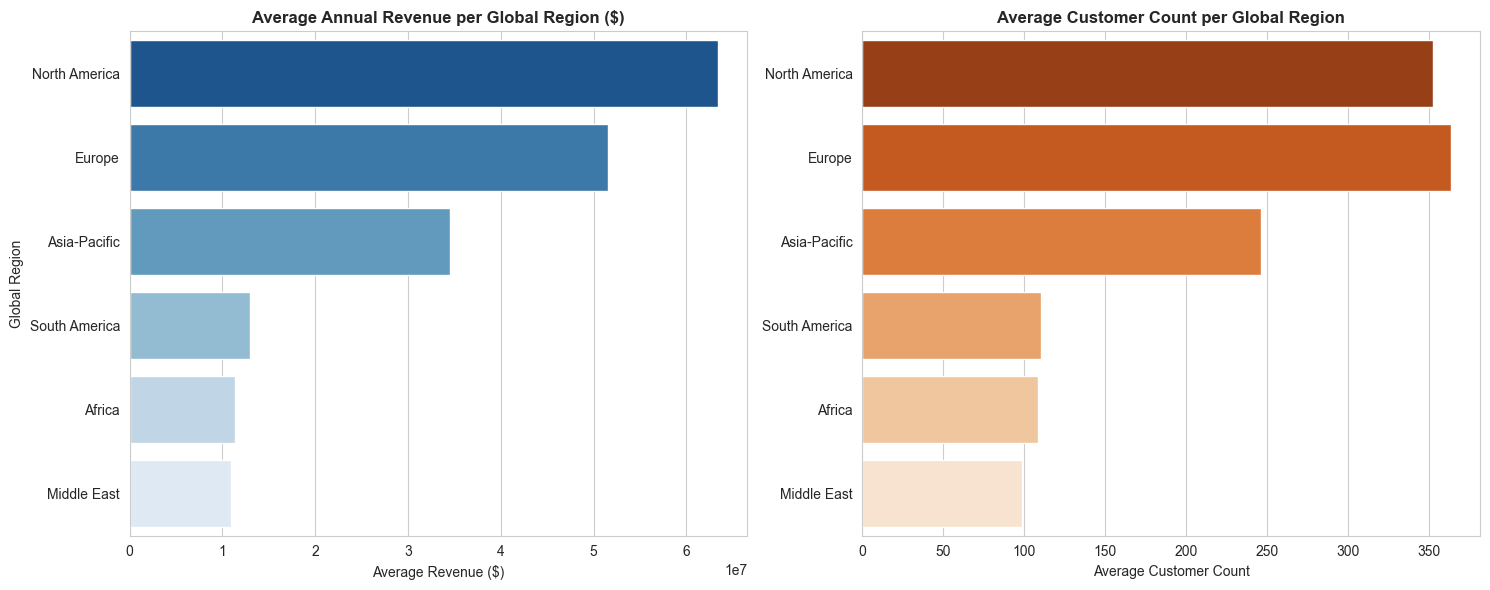

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

region_stats = rpa_companies.groupby('global_region').agg(
    avg_revenue=('annual_revenue_usd', 'mean'),
    avg_customers=('customer_count', 'mean')
).reset_index().sort_values(by='avg_revenue', ascending=False)

sns.barplot(data=region_stats, x='avg_revenue', y='global_region', ax=axes[0], palette='Blues_r')
axes[0].set_title('Average Annual Revenue per Global Region ($)', fontweight='bold')
axes[0].set_xlabel('Average Revenue ($)')
axes[0].set_ylabel('Global Region')

sns.barplot(data=region_stats, x='avg_customers', y='global_region', ax=axes[1], palette='Oranges_r')
axes[1].set_title('Average Customer Count per Global Region', fontweight='bold')
axes[1].set_xlabel('Average Customer Count')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('img/regional_business_scale.png', dpi=300, bbox_inches='tight')
plt.show()


### Insight (Regional Business Scale Analysis)

* **North America & Europe Dominance:**
  * North American companies lead the market in financial scale, generating the highest average annual revenue (approx. **$63.3 Million**), closely followed by European companies (approx. **$51.5 Million**).
  
* **Customer Base and Market Maturity:**
  * Europe commands the largest active customer footprint per company on average (approx. **363 customers**), slightly edgeing out North America (**352 customers**). 
  * Asia-Pacific occupies the middle-tier market, while South America, Africa, and the Middle East lag behind with smaller company scales (averaging under $13 Million revenue and around 100 customers).
  
* **Geographical RPA Maturity Indicator:**
  * This distribution highlights the maturity of RPA market adoption globally, where established Western markets (North America and Europe) represent highly capitalized and dense environments compared to emerging regional markets.


### 3.12 Is There a Correlation Between Cloud Readiness and AI Integration in RPA Companies?

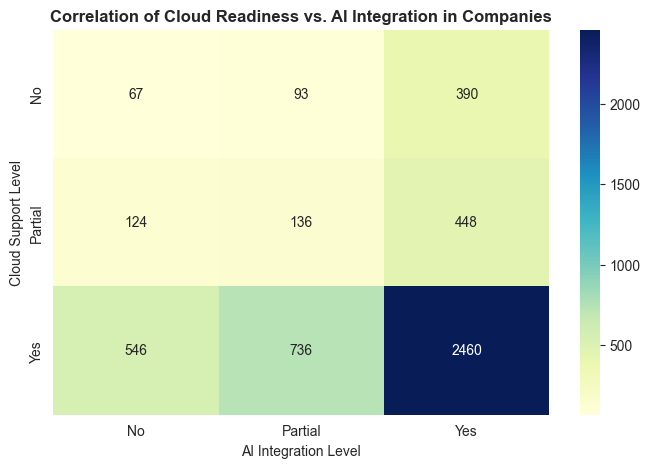

In [36]:
crosstab_capabilities = pd.crosstab(rpa_companies['cloud_support'], rpa_companies['ai_integration'])

plt.figure(figsize=(8, 5))
sns.heatmap(crosstab_capabilities, annot=True, fmt='d', cmap='YlGnBu', cbar=True)
plt.title('Correlation of Cloud Readiness vs. AI Integration in Companies', fontweight='bold', fontsize=12)
plt.xlabel('AI Integration Level')
plt.ylabel('Cloud Support Level')
plt.savefig('img/capabilities_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### Insight (Capabilities Correlation Analysis)

* **Strong Capability Clustering (Digital Maturity):**
  * There is a highly concentrated clustering of companies in the **Yes-Yes** quadrant, where **2,460 companies** (nearly 50% of the entire database) possess both full Cloud Support and full AI Integration.
  
* **Sparse Low-Capability Sector:**
  * In contrast, the **No-No** quadrant (No Cloud Support & No AI Integration) is extremely sparse with only **67 companies**. This indicates that companies without cloud readiness are very rare, and they almost never integrate AI capabilities.
  
* **Strategic Coupling of Modern Tech:**
  * The heatmap demonstrates that Cloud Support and AI Integration are strongly coupled capabilities. RPA providers and enterprises typically view Cloud migration and AI enablement not as independent choices, but as joint components of their digital maturity roadmap.

### 3.13 How Does Project Duration Relate to ROI and Annual Savings?

In [37]:
completed_bot = auto_projects[auto_projects['project_status'] == 'Completed'].copy()

completed_bot['start_date'] = pd.to_datetime(completed_bot['start_date'])
completed_bot['completion_date'] = pd.to_datetime(completed_bot['completion_date'])

completed_bot['duration(days)'] = (completed_bot['completion_date'] - completed_bot['start_date']).dt.days
completed_bot.head()

,project_id,company_id,project_name,start_date,completion_date,project_status,automation_type,robots_deployed,budget_usd,annual_savings_usd,roi_percent,department,implementation_partner,country,industry,employee_hours_saved,ai_enabled,cloud_deployment,DateTime,duration(days)
1,PRJ000002,CMP04395,Sentinel Process Reengineering,2023-07-29,2024-03-16,Completed,Claims Processing,44,1069470,579652,54.2,Customer Onboarding,Tech Mahindra,South Africa,Mining & Metals,31856,No,Yes,2023-07-29,231
2,PRJ000003,CMP01477,Sentinel Task Automation,2021-03-10,2022-12-22,Completed,Email Automation,18,43509,23494,54.0,Finance & Accounting,EXL Service,United States,Nonprofit & NGO,5935,No,Yes,2021-03-10,652
3,PRJ000004,CMP00578,Robust Automation Platform,2023-12-30,2024-12-15,Completed,Order Processing,6,99001,107812,108.9,Finance & Accounting,Birlasoft,Italy,Banking & Financial Services,9491,Yes,Yes,2023-12-30,351
5,PRJ000006,CMP00868,Phantom Workforce Digitization,2017-06-18,2018-02-28,Completed,HR Onboarding,14,121789,547928,449.9,Fraud Detection,Tata Consultancy Services,New Zealand,Professional Services & Consulting,81217,No,Yes,2017-06-18,255
6,PRJ000007,CMP01179,Unified Hyperautomation,2020-08-19,2020-10-07,Completed,IT Helpdesk,36,425952,2129760,500.0,IT & Technology,Aricent,United Kingdom,Insurance,411719,No,Yes,2020-08-19,49


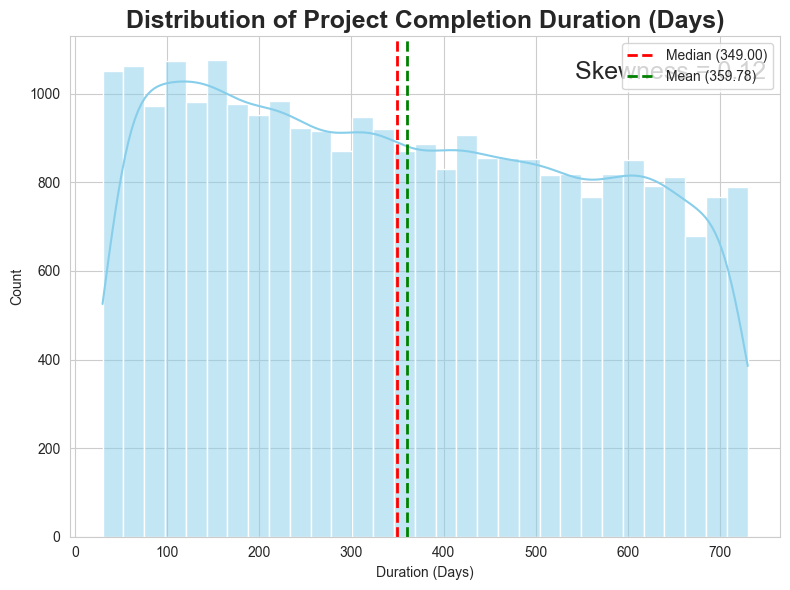

In [38]:
plt.figure(figsize=(8, 6))

sns.histplot(
    data=completed_bot,
    x='duration(days)',
    bins='auto',
    kde=True,
    color='skyblue'
)

mean_val = completed_bot['duration(days)'].mean()
median_val = completed_bot['duration(days)'].median()
skew_val = completed_bot['duration(days)'].skew()

plt.axvline(median_val, color='red', linestyle='--', linewidth=2, label=f'Median ({median_val:.2f})')
plt.axvline(mean_val, color='green', linestyle='--', linewidth=2, label=f'Mean ({mean_val:.2f})')
plt.title('Distribution of Project Completion Duration (Days)', fontsize=18, fontweight='bold')

plt.xlabel('Duration (Days)')
plt.ylabel('Count')

plt.text(
    0.98, 0.95, f'Skewness = {skew_val:.2f}',
    transform=plt.gca().transAxes,
    ha='right',
    va='top',
    fontsize=18,
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.8
    )
)

plt.legend()
plt.tight_layout()

filepath = os.path.join('img', 'Distribution of Project Completion Duration (Days).png')
plt.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


### Insight (Project Duration Distribution)

* **1-Year Average Lifecycle:**
  * The mean project duration is **359.78 days** (approx. 1 year) and the median is **349.00 days**, indicating that the standard timeline to complete an RPA project in this dataset is centered around a one-year window.

* **Approximately Symmetric Distribution:**
  * The distribution exhibits a low skewness of **0.12**, representing an approximately symmetric spread of data. This reflects a balanced mix of short-term "quick-win" projects and long-term enterprise transformations.

* **Synthetic Data Signature:**
  * In the real world, project durations are typically heavily right-skewed (most projects finish in 1-4 months). The uniform and symmetric distribution across the 2-year range further confirms the synthetic nature of this dataset.


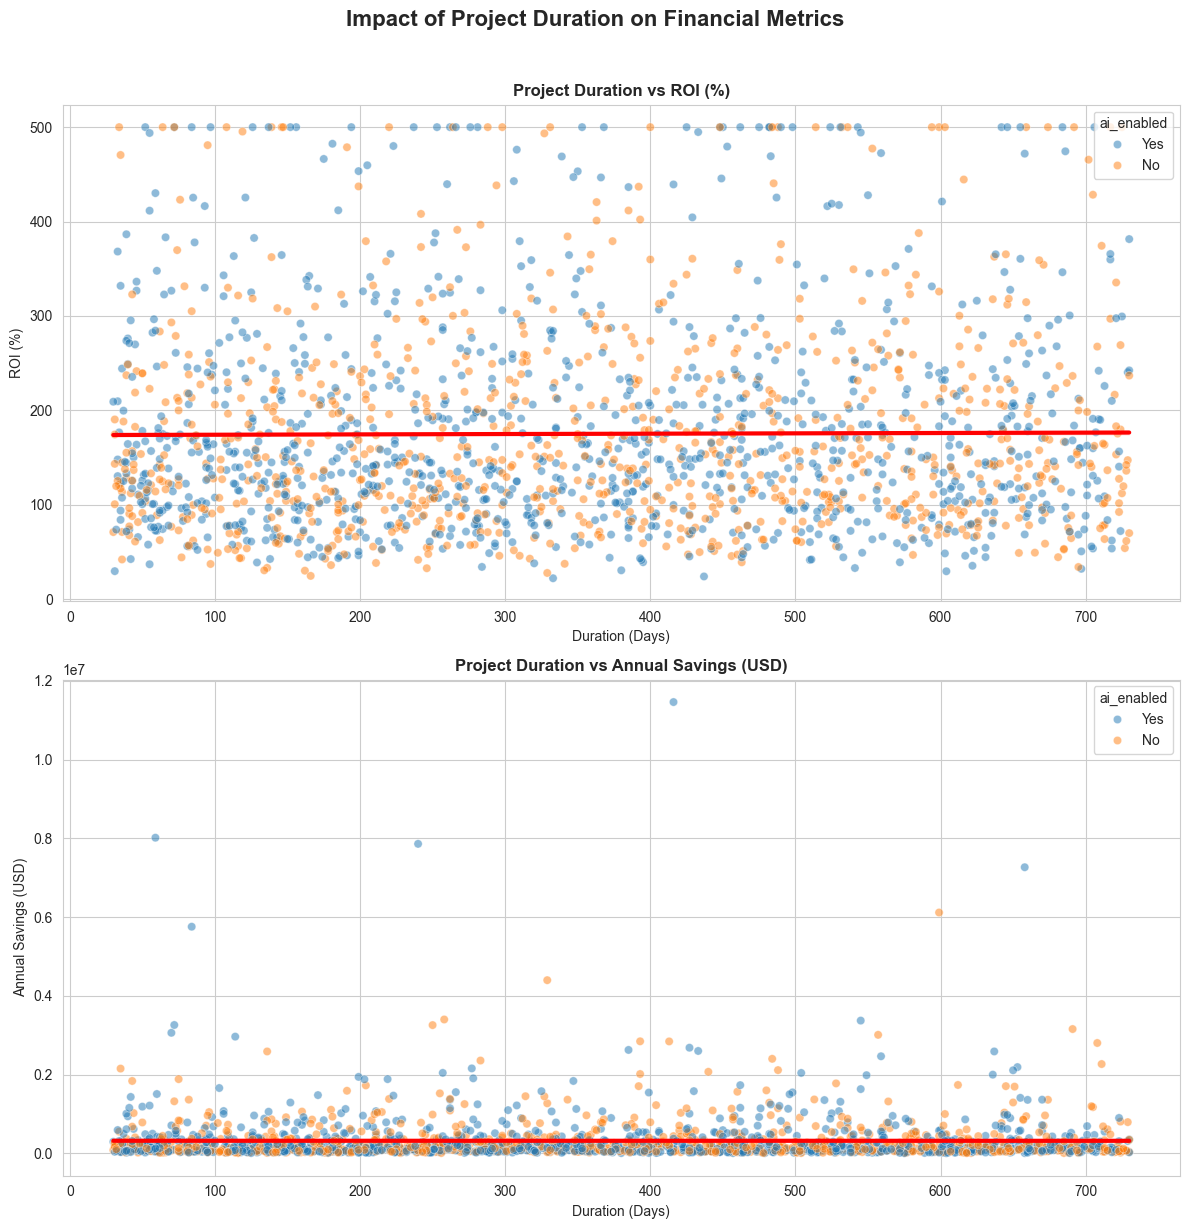

In [39]:
metrics = ['roi_percent', 'annual_savings_usd']
titles = ['Project Duration vs ROI (%)', 'Project Duration vs Annual Savings (USD)']
y_labels = ['ROI (%)', 'Annual Savings (USD)']

fig, ax = plt.subplots(2, 1, figsize=(12, 12))
ax = ax.flatten()

df_sample = completed_bot.sample(n=2000, random_state=42)

for i, col in enumerate(metrics):
    sns.scatterplot(
        data=df_sample, 
        x='duration(days)',
        y=col,
        hue='ai_enabled',
        ax=ax[i],
        alpha=0.5
    )

    sns.regplot(
        data=completed_bot, 
        x='duration(days)',
        y=col,
        scatter=False,
        ax=ax[i],
        color='red',
        line_kws={'linewidth': 3, 'zorder': 5} 
    )
    
    ax[i].set_title(titles[i], fontsize=12, fontweight='bold')
    ax[i].set_xlabel('Duration (Days)')
    ax[i].set_ylabel(y_labels[i])

plt.suptitle('Impact of Project Duration on Financial Metrics', fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()

filepath = os.path.join('img', 'Project_Duration_vs_Financial_Metrics.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()


### Insight (Project Duration vs. Financial Outcomes)

* **No Correlation with Financial Metrics:**
  * The regression line is virtually flat, indicating a correlation near **0.00** between project duration and financial outcomes. Projects completed in under 3 months yield almost identical ROI (approx. **175%**) and Annual Savings compared to projects taking over 2 years.

* **Strategic Recommendation (Focus on "Quick Wins"):**
  * Since longer project timelines do not generate superior financial returns, organizations should prioritize short-term, high-impact RPA initiatives. Quick-win deployments offer faster time-to-value without any loss in return efficiency.

* **Confirmation of Synthetic Data Structure:**
  * The completely uniform and scattered distribution of data points across the 2-year duration spectrum further confirms the synthetic and mathematically randomized nature of this database.


## Chapter 4 : Machine Learning

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, TargetEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor

### 4.1 Feature Engineering

In [41]:
auto_projects['savings_to_budget_ratio'] = auto_projects['annual_savings_usd'] / auto_projects['budget_usd']
auto_projects['cost_per_robot'] = auto_projects['budget_usd'] / auto_projects['robots_deployed']
auto_projects['hours_saved_per_robot'] = auto_projects['employee_hours_saved'] / auto_projects['robots_deployed']
auto_projects['savings_per_robot'] = auto_projects['annual_savings_usd'] / auto_projects['robots_deployed']
auto_projects['savings_per_hour_saved'] = auto_projects['annual_savings_usd'] / auto_projects['employee_hours_saved']
auto_projects['start_year'] = auto_projects['start_date'].dt.year
auto_projects['start_month'] = auto_projects['start_date'].dt.month
auto_projects.head()

,project_id,company_id,project_name,start_date,completion_date,project_status,automation_type,robots_deployed,budget_usd,annual_savings_usd,...,ai_enabled,cloud_deployment,DateTime,savings_to_budget_ratio,cost_per_robot,hours_saved_per_robot,savings_per_robot,savings_per_hour_saved,start_year,start_month
0,PRJ000001,CMP04872,Prism Automation Initiative,2017-04-23,NaT,Active,Customer Onboarding,27,10889,17248,...,Yes,Yes,2017-04-23,1.583984,403.296296,2590.518519,638.814815,0.246597,2017,4
1,PRJ000002,CMP04395,Sentinel Process Reengineering,2023-07-29,2024-03-16,Completed,Claims Processing,44,1069470,579652,...,No,Yes,2023-07-29,0.541999,24306.136364,724.000000,13173.909091,18.196007,2023,7
2,PRJ000003,CMP01477,Sentinel Task Automation,2021-03-10,2022-12-22,Completed,Email Automation,18,43509,23494,...,No,Yes,2021-03-10,0.539980,2417.166667,329.722222,1305.222222,3.958551,2021,3
3,PRJ000004,CMP00578,Robust Automation Platform,2023-12-30,2024-12-15,Completed,Order Processing,6,99001,107812,...,Yes,Yes,2023-12-30,1.088999,16500.166667,1581.833333,17968.666667,11.359393,2023,12
4,PRJ000005,CMP02586,Nexus Automation Platform,2024-09-08,NaT,Active,Customer Onboarding,21,122055,255949,...,Yes,Yes,2024-09-08,2.096997,5812.142857,1271.095238,12188.047619,9.588619,2024,9


### 4.2 Normalize Data and Encode the Feature

In [42]:
num_features = [
    'budget_usd', 'robots_deployed', 'annual_savings_usd',
    'employee_hours_saved', 'cost_per_robot', 'savings_to_budget_ratio',
    'hours_saved_per_robot', 'savings_per_robot', 'savings_per_hour_saved',
    'start_year', 'start_month'
]

categorical_features = [
    'industry', 'department', 'ai_enabled', 'cloud_deployment',
    'automation_type', 'implementation_partner', 'country', 'project_status' 
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num',PowerTransformer(method='yeo-johnson') , num_features), 
        ('cat', TargetEncoder(smooth='auto', random_state=42), categorical_features)
    ]
)

### 4.3 Train-Test Split

In [43]:
X = auto_projects[num_features + categorical_features]
y = auto_projects['roi_percent']

X_train, X_test, y_train, y_test = train_test_split(
                    X, y, test_size=0.2,random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (40000, 19)
X_test shape: (10000, 19)
y_train shape: (40000,)
y_test shape: (10000,)


### 4.4 Model Training

In [44]:
cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=100
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', cat_model)
])

print("Training...")
pipeline.fit(X_train, y_train)
print("Training Complete.")

Training...


c:\Users\FATHIR\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


0:	learn: 98.9701595	total: 179ms	remaining: 2m 59s
100:	learn: 1.9347854	total: 946ms	remaining: 8.42s
200:	learn: 1.3707775	total: 2s	remaining: 7.93s
300:	learn: 1.1829588	total: 2.89s	remaining: 6.7s
400:	learn: 1.0746400	total: 3.75s	remaining: 5.61s
500:	learn: 1.0042915	total: 4.64s	remaining: 4.62s
600:	learn: 0.9555472	total: 5.63s	remaining: 3.74s
700:	learn: 0.9136712	total: 6.83s	remaining: 2.91s
800:	learn: 0.8806497	total: 7.89s	remaining: 1.96s
900:	learn: 0.8533194	total: 9.01s	remaining: 990ms
999:	learn: 0.8264089	total: 11s	remaining: 0us
Training Complete.


### 4.5 Evaluation Model

In [45]:
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=== EVALUATION RESULT ===")
print(f"Mean Absolute Error (MAE) : {mae:.4f} %")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} %")
print(f"R-squared (R2 Score)       : {r2:.4f}")


=== EVALUATION RESULT ===
Mean Absolute Error (MAE) : 0.5779 %
Root Mean Squared Error (RMSE): 0.9408 %
R-squared (R2 Score)       : 0.9999


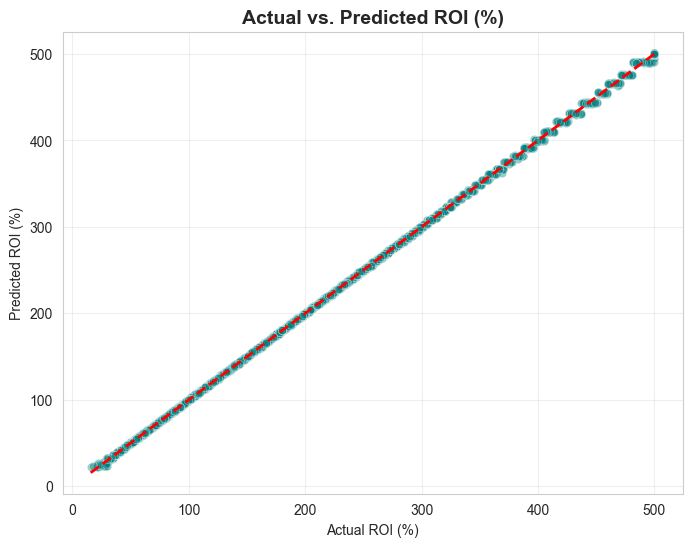

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')

plt.title('Actual vs. Predicted ROI (%)', fontsize=14, fontweight='bold')
plt.xlabel('Actual ROI (%)')
plt.ylabel('Predicted ROI (%)')
plt.grid(True, alpha=0.3)

filepath = os.path.join('img', 'Actual_vs_Predicted.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


C:\Users\FATHIR\AppData\Local\Temp\ipykernel_23068\1361796543.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


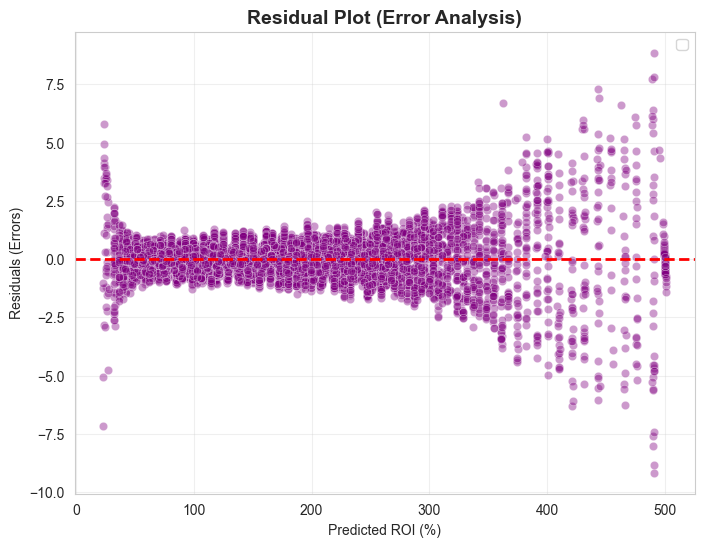

In [48]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.4, color='purple')
plt.axhline(y=0, color='red', linestyle='--', lw=2)

plt.title('Residual Plot (Error Analysis)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted ROI (%)')
plt.ylabel('Residuals (Errors)')
plt.grid(True, alpha=0.3)
plt.legend()

filepath = os.path.join('img', 'Residual_plot.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
